In [1]:
import numpy as np
from farm.plant import Plant
from farm import Climate
from farm import Soil
from farm import Crop
from farm import CropModel
from farm.climate import make_climate_parameters
from farm.functions import evolved_calc_yield, plot_lin_regression
import pandas as pd
from pandas import DataFrame
from numpy import zeros
import matplotlib.pyplot as plt

/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
# ── Publication style defaults ──────────────────────────────────────────────
# Run this cell before any figure cell.
# Sets global rcParams (font sizes, legend, savefig DPI) and two helpers:
#   pub_label(ax, "(a)") — bold panel label at top-left
#   despine(ax)          — remove top and right spines
import matplotlib as mpl
import os; os.makedirs("output", exist_ok=True)

mpl.rcParams.update({
    "font.size":       10,
    "axes.labelsize":  11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon":  False,
    "savefig.dpi":     300,
    "savefig.bbox":    "tight",
})

def pub_label(ax, label, x=-0.08, y=1.02):
    """Bold panel label — (a), (b), … — at top-left of an axes."""
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="bottom", ha="left")

def despine(ax):
    """Remove top and right spines (journal standard)."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

In [3]:
# Fit Y_MAX regression from Kenya Seed Co. data (yield in kg/acre vs. days-to-maturity).
# Passing m and b explicitly avoids the internal /1000 unit issue in evolved_calc_yield.
_yd = pd.read_csv('data/Yields/hybrid_yields_verified.csv')
_, _m_yield, _b_yield = plot_lin_regression(
    _yd.verified_days_to_maturity,
    _yd.verified_yield_kg_acre,
    'verified_days_to_maturity', 'verified_yield_kg_acre', _yd,
    positive=False
)

In [4]:
# Pre-compute CETRAD OL JOGI FARM monthly parameters once.
# Re-reading the CSV in a tight loop adds ~50 ms per iteration; pre-computing
# and passing alpha_r / lambda_r directly avoids this overhead in simulations.
CLIMATE_KWARGS = dict(
    station='OL JOGI FARM',
    data_file='data/CETRAD/CETRAD_rainfall.csv',
    interval='month',
)
_alpha_cetrad, _lambda_cetrad, _ = make_climate_parameters(**CLIMATE_KWARGS)
_CLIMATE_KWARGS_FAST = dict(alpha_r=_alpha_cetrad, lambda_r=_lambda_cetrad)

# Sanity check — should be ~376 mm over 247-day window, 555 mm/yr annual.
_mean_daily_rf = sum(a * l for a, l in zip(_alpha_cetrad, _lambda_cetrad)) / 12
print(f"CETRAD expected annual RF: {_mean_daily_rf * 365:.0f} mm/yr  "
      f"({_mean_daily_rf * 247:.0f} mm / 247-day season)")


CETRAD expected annual RF: 555 mm/yr  (376 mm / 247-day season)


## Model definitions

In [5]:
class Tree(Plant):
    """
    Simple tree component for agroforestry modeling.

    canopy_cover  : fraction of plot area covered by tree canopy [0-1].
                    Scales all plot-level tree fluxes (T, shade, HR).
                    Typical parkland agroforestry: 0.10 - 0.30.
    leaf_fraction : fraction of the 180-day crop season the tree carries leaves [0-1].
                    0.0 → leafless entire crop season (Faidherbia albida style:
                          no competition, no shade during crop season; HR still
                          operates via deep roots).
                    0.1 → leafed for first ~18 days, then dormant (~1-month overlap
                          before Faidherbia sheds leaves, per Roupsard 1999).
                    1.0 → leafed entire crop season (evergreen co-season tree).
                    Outside the crop season the tree is always active (kc=1.0).
                    Ref: Roupsard et al. (1999), Bayala & Prieto (2020).
    """
    def __init__(self, kc=1.0, LAI_max=2.0, canopy_cover=0.2,
                 leaf_fraction=1.0, *args, **kwargs):
        self.kc = kc
        self.LAI_max = LAI_max
        self.canopy_cover = canopy_cover
        self.leaf_fraction = leaf_fraction
        super().__init__(*args, **kwargs)

    def calc_LAI(self):
        return self.LAI_max

    def calc_I(self, LAI=None, int_efficiency=0.5):
        LAI_use = self.calc_LAI() if LAI is None else LAI
        return LAI_use * int_efficiency

    def calc_T(self, s, LAI=None, kc=None):
        kc_use = self.kc if kc is None else kc
        if s >= self.s_star:
            return kc_use * self.T_MAX
        elif s >= self.sw:
            return (s - self.sw) / (self.s_star - self.sw) * (kc_use * self.T_MAX)
        else:
            return 0.0


In [6]:
def shade_factor(LAI_tree, canopy_cover=1.0, k_shade=0.35):
    """
    Plot-average fraction of incoming radiation (and thus PET) remaining after tree shading.

    Spatial weighted average: under-canopy fraction (cc) attenuated by Beer-Lambert
    extinction, plus open-sky fraction (1-cc) at full radiation:

        sf = cc * exp(-k_s * LAI_tree) + (1 - cc)

    Caylor et al. (2005): k_s = 0.35 for savanna parkland.
    Applied to both E and T_crop via Priestley-Taylor: PET proportional to available energy Q.

    LAI_tree    : tree leaf area index (stand-level, NOT pre-multiplied by canopy_cover)
    canopy_cover: fraction of plot area under tree canopy [0-1]
    k_shade     : extinction coefficient [-]; 0.35 from Caylor et al. 2005

    Returns value in (0, 1].
    """
    return canopy_cover * np.exp(-k_shade * LAI_tree) + (1.0 - canopy_cover)


In [7]:
class TreeCropModel:
    def __init__(self, soil=None, climate=None, crop=None, tree=None, hr_max=1.0):
        """
        hr_max : plot-level hydraulic redistribution capacity [mm/day].
                 NOT scaled by canopy_cover — hr_max is already a plot-level rate.
                 HR flux is proportional to the water-potential gradient (Clapp-Hornberger),
                 normalised so hr_max is the flux when s_deep ≈ s_fc and s_top ≈ crop sw.
                 Literature: 0.1-1.0 mm/night at plot scale in savanna parkland
                 (Burgess et al. 2001, Caldwell et al. 1991, Bayala & Prieto 2020).
        """
        self.soil = soil
        self.crop = crop
        self.tree = tree
        self.climate = climate
        self.hr_max = hr_max

        self.nZr_top = soil.set_nZr(self.crop)

        class _Tmp: pass
        tmp = _Tmp()
        tmp.Zr = max(self.tree.Zr - self.crop.Zr, 0.0)
        self.nZr_deep_full = soil.set_nZr(tmp) if tmp.Zr > 0 else 0.0

        # Reference Δψ for HR normalisation [MPa]:
        # ψ at field capacity (deep, well-watered) minus ψ at crop wilting point (top, dry).
        # Ensures hr_max [mm/day] is the flux when s_deep ≈ s_fc and s_top ≈ crop sw.
        psi_fc = soil.Psi_S_MPa * soil.sfc ** (-soil.b)
        psi_sw = soil.Psi_S_MPa * self.crop.sw ** (-soil.b)
        self._delta_psi_ref = abs(psi_sw - psi_fc)  # MPa > 0

    def _calc_L(self, s0, nZr):
        """Laio (2001) gravity drainage for a soil layer with given nZr [mm/day].
        Same physics as soil.calc_L() but accepts nZr directly rather than requiring
        soil.nZr to be set, so it works correctly for both the top and deep layers.
        """
        Lmax = s0 - self.soil.sfc
        if Lmax > 0 and nZr > 0:
            beta = 2 * self.soil.b + 4
            m = self.soil.Ks / (nZr * (np.exp(beta * (1 - self.soil.sfc)) - 1))
            L = (1 / beta) * np.log(
                np.exp(beta * (s0 - self.soil.sfc))
                - np.exp(-m * beta) * (np.exp(beta * (s0 - self.soil.sfc)) - 1))
            return min(L, Lmax) * nZr
        return 0.0

    def pre_allocate(self):
        n = self.n_days
        self.R          = zeros(n)
        self.s_top      = zeros(n + 1)
        self.s_deep     = zeros(n + 1)
        self.ET         = zeros(n)
        self.I          = zeros(n)
        self.E          = zeros(n)
        self.T          = zeros(n)
        self.L          = zeros(n)
        self.Q          = zeros(n)
        self.HR         = zeros(n)   # hydraulic redistribution flux [mm/day]
        self.kc_tree    = zeros(n)   # effective tree kc (0 when dormant, i.e. past leaf_fraction×lgp days)
        self.dos        = zeros(n)
        self.dsdt       = zeros(n)
        self.LAI        = zeros(n)
        self.kc         = zeros(n)
        self.stress     = zeros(n)
        self.T_tree     = zeros(n)
        self.ET_crop    = zeros(n)
        self.ET_tree    = zeros(n)
        self.T_tree_top = zeros(n)
        self.T_tree_deep= zeros(n)

    def run(self, do_output=False, s0=0.3, planting_date=100,
            t_before=60, t_after=7,
            deep_roots=True, shade_on=True, hr_on=True, ci_on=True,
            s_deep_0=None):
        """
        deep_roots : trees access the deep layer (default True)
        shade_on   : tree canopy reduces PET under canopy (default True).
                     Shade attenuates incoming radiation (Beer-Lambert, k=0.35;
                     Caylor et al. 2005), reducing available energy Q for all ET.
                     Applied to both E and T_crop (Priestley-Taylor: PET ∝ Q).
        hr_on      : hydraulic redistribution active (default True).
                     Trees passively lift water from deep to top when s_deep > s_top.
        ci_on      : tree canopy interception active (default True).
                     When False, only crop interception is computed.
        """
        self.planting_date = planting_date
        self.n_days = t_before + self.crop.lgp + t_after
        self.pre_allocate()
        self.nZr_deep = self.nZr_deep_full if deep_roots else 0.0

        self.doy_start = self.planting_date - t_before
        if self.doy_start <= 0:
            self.doy_start = 365 + self.doy_start

        doy = np.arange(self.doy_start, self.doy_start + self.n_days)
        while (doy - 365 > 0).any():
            doy = doy - 365 * ((doy - 365) > 0)

        for t in range(self.n_days):
            self.R[t] = self.climate.rainfall[doy[t] - 1]
        self.doy = doy

        # Both layers start at s0: no artificial deep-layer wetness at initialisation.
        # Pre-season Laikipia vadose zone is depleted, not near field capacity.
        # Use spin_up() or pass explicit s_deep_0 when a specific initial condition is needed.
        self.s_top[0]  = s0
        self.s_deep[0] = s_deep_0 if s_deep_0 is not None else s0
        dos = 0
        planted = False

        for t in range(self.n_days):
            if self.doy[t] == self.planting_date:
                planted = True
            if planted:
                dos += 1

            self.dos[t] = dos
            self.kc[t]  = self.crop.calc_kc(dos)
            self.LAI[t] = self.crop.calc_LAI(self.kc[t])
            self.stress[t] = self.crop.calc_stress(self.s_top[t])  # beginning-of-day, matches CropModel

            # --- Tree phenology: kc and LAI for this timestep
            # leaf_fraction controls what fraction of the crop season the tree carries leaves.
            # 0.0 → dormant entire crop season (Faidherbia albida style).
            # 1.0 → leafed entire crop season (evergreen co-season tree).
            # Outside the crop season the tree is always active (kc=1.0).
            in_crop_season = planted and 0 < dos <= self.crop.lgp
            leaf_day_limit = self.tree.leaf_fraction * self.crop.lgp
            if in_crop_season and dos > leaf_day_limit:
                tree_kc  = 0.0   # dormant: past leaf-carrying window this season
                tree_LAI = 0.0
            else:
                tree_kc  = self.tree.kc
                tree_LAI = self.tree.calc_LAI()
            self.kc_tree[t] = tree_kc

            self.Q[t] = self.soil.calc_Q(self.s_top[t], units="mm/day")

            # --- Interception: crop + tree canopy (Fix 5)
            # Tree interception is scaled by canopy_cover (plot-level fraction).
            # For leaf_fraction=0.0, tree_LAI=0 during crop season → no tree interception.
            # ci_on=False isolates tree interception as a mechanism (for experiments).
            I_crop = self.crop.calc_I(self.LAI[t])
            I_tree = self.tree.calc_I(LAI=tree_LAI) * self.tree.canopy_cover if ci_on else 0.0
            self.I[t] = min(I_crop + I_tree, self.R[t])
            rainfall  = max(self.R[t] - self.I[t], 0.0)

            s_top  = self.s_top[t]
            s_deep = self.s_deep[t]

            # --- Rainfall input to top layer
            s_top += (rainfall - self.Q[t]) / self.nZr_top

            # --- Top-layer drainage (Fix 3 extended)
            # Same Laio (2001) physics as the published CropModel single-layer drainage.
            # Routes to deep layer if present; exits as L if nZr_deep=0 (deep_roots=False).
            # This ensures monoculture equivalence: TreeCropModel with a ghost tree
            # (deep_roots=False, T_MAX=0, canopy_cover=0) matches CropModel exactly.
            if s_top > self.soil.sfc:
                perc_mm = self._calc_L(s_top, self.nZr_top)
                s_top  -= perc_mm / self.nZr_top
                if self.nZr_deep > 0:
                    s_deep += perc_mm / self.nZr_deep
                else:
                    self.L[t] += perc_mm

            # --- Saturation overflow
            if s_top > 1.0:
                excess_mm = (s_top - 1.0) * self.nZr_top
                s_top = 1.0
                if self.nZr_deep > 0:
                    s_deep += excess_mm / self.nZr_deep
                else:
                    self.L[t] += excess_mm

            # --- Hydraulic redistribution: deep -> top driven by Δψ (Fix 1)
            # Flux is proportional to the Clapp-Hornberger water-potential gradient,
            # normalised by Δψ_ref (s_fc → sw) so hr_max [mm/day] is the flux at the
            # maximum agronomically relevant gradient. Operates regardless of leaf_fraction.
            # Ref: Caldwell et al. (1991), Burgess et al. (2001), Bayala & Prieto (2020)
            if hr_on and self.nZr_deep > 0 and s_deep > s_top:
                psi_top  = self.soil.Psi_S_MPa * max(s_top,  1e-6) ** (-self.soil.b)
                psi_deep = self.soil.Psi_S_MPa * max(s_deep, 1e-6) ** (-self.soil.b)
                delta_psi = max(psi_deep - psi_top, 0.0)  # MPa, positive when deep wetter
                hr_flux = min(
                    self.hr_max * delta_psi / self._delta_psi_ref,
                    s_deep * self.nZr_deep,
                    (1.0 - s_top) * self.nZr_top
                )
                s_top  += hr_flux / self.nZr_top
                s_deep -= hr_flux / self.nZr_deep
                self.HR[t] = hr_flux

            # --- Tree transpiration (scaled by canopy_cover; uses leaf_fraction-aware kc)
            T_tree_canopy_pot  = self.tree.calc_T(1.0,              kc=tree_kc) * self.tree.canopy_cover
            T_tree_top_supply  = self.tree.calc_T(max(s_top,  0.0), kc=tree_kc) * self.tree.canopy_cover
            T_tree_deep_supply = self.tree.calc_T(max(s_deep, 0.0), kc=tree_kc) * self.tree.canopy_cover
            T_tree_soil_supply = T_tree_top_supply + T_tree_deep_supply

            T_tree_total_pot = min(T_tree_canopy_pot, T_tree_soil_supply)

            # Deep-first: tree preferentially uses deep roots, falling back to
            # shallow only when deep supply is exhausted. Ecophysiologically
            # correct for Faidherbia — its taproot system evolved specifically
            # to access deep water unavailable to crops.
            T_tree_deep_pot = min(T_tree_total_pot, T_tree_deep_supply)
            T_tree_top_pot  = max(T_tree_total_pot - T_tree_deep_pot, 0.0)

            # --- Crop + soil evaporation (microclimate: shade reduces available radiation)
            # Beer-Lambert attenuation of incoming shortwave (k=0.35; Caylor et al. 2005)
            # reduces available energy Q under the canopy. In a Priestley-Taylor framework,
            # PET ∝ Q, so shade lowers atmospheric demand for both E and T_crop.
            s_eff = max(s_top, 0.0)
            T_crop_pot = self.crop.calc_T(s_eff, LAI=self.LAI[t])
            E_pot      = self.climate.calc_E(s_eff, LAI=self.LAI[t], sh=self.soil.sh)
            sf = shade_factor(tree_LAI, self.tree.canopy_cover) if shade_on else 1.0
            E_pot      *= sf
            T_crop_pot *= sf

            # --- Top-layer allocation (ration when demand > supply)
            demand_top    = T_tree_top_pot + T_crop_pot + E_pot
            available_top = s_top * self.nZr_top
            if demand_top <= available_top:
                T_tree_shallow = T_tree_top_pot
                T_crop_actual  = T_crop_pot
                E_actual       = E_pot
            else:
                scale = available_top / demand_top if demand_top > 0 else 0.0
                T_tree_shallow = T_tree_top_pot * scale
                T_crop_actual  = T_crop_pot     * scale
                E_actual       = E_pot          * scale
            s_top -= (T_tree_shallow + T_crop_actual + E_actual) / self.nZr_top

            # --- Deep-layer tree uptake (backfill if shallow was rationed)
            # If top-layer rationing reduced tree's shallow uptake, compensate from deep,
            # capped by deep moisture supply and total canopy potential.
            T_tree_deep_pot = min(T_tree_total_pot - T_tree_shallow, T_tree_deep_supply)
            T_tree_deep = 0.0
            if T_tree_deep_pot > 0 and self.nZr_deep > 0:
                T_tree_deep = min(T_tree_deep_pot, s_deep * self.nZr_deep)
                s_deep -= T_tree_deep / self.nZr_deep

            T_tree_actual = T_tree_shallow + T_tree_deep

            # --- Save fluxes
            self.T_tree[t]      = T_tree_actual
            self.T[t]           = T_crop_actual
            self.E[t]           = E_actual
            self.ET_crop[t]     = T_crop_actual + E_actual
            self.ET_tree[t]     = T_tree_actual
            self.ET[t]          = self.ET_crop[t] + self.ET_tree[t]
            self.T_tree_top[t]  = T_tree_shallow
            self.T_tree_deep[t] = T_tree_deep

            # --- Deep layer gravity drainage (Fix 2: Laio 2001, same physics as top layer)
            # Water above field capacity in the deep layer drains out of the system.
            # Without this, deep water is unrealistically permanent once it percolates.
            if self.nZr_deep > 0:
                L_deep = self._calc_L(s_deep, self.nZr_deep)
                s_deep -= L_deep / self.nZr_deep
                self.L[t] += L_deep

            # --- Deep saturation overflow
            if s_deep > 1.0:
                self.L[t] += (s_deep - 1.0) * self.nZr_deep
                s_deep = 1.0

            self.s_top[t+1]  = max(s_top,  0.0)
            self.s_deep[t+1] = max(s_deep, 0.0)
            total_now  = self.s_top[t]   * self.nZr_top + self.s_deep[t]   * self.nZr_deep
            total_next = self.s_top[t+1] * self.nZr_top + self.s_deep[t+1] * self.nZr_deep
            self.dsdt[t] = total_next - total_now

        if do_output:
            return self.output()

    def spin_up(self, n_seasons=5, s0=0.3, s_deep_0=None, **run_kwargs):
        """
        Run N silent seasons to converge initial conditions.
        Chains end-of-season s_top → next s0, s_deep → next s_deep_0.
        Returns (s_top_converged, s_deep_converged) as scalars.

        n_seasons=5 is sufficient for deep-layer convergence under typical
        Laikipia climatologies (convergence usually within 2-3 seasons).
        The same stochastic rainfall sequence is reused each spin-up season,
        which is acceptable because the goal is vadose-zone convergence, not
        full interannual variability during spin-up.
        """
        s_t = s0
        s_d = s_deep_0 if s_deep_0 is not None else s0
        for _ in range(n_seasons):
            self.run(s0=s_t, s_deep_0=s_d, **run_kwargs)
            out = self.output()
            s_t = float(out["s_top"].iloc[-1])
            s_d = float(out["s_deep"].iloc[-1])
        return s_t, s_d

    def output(self):
        return DataFrame({
            "kc":         self.kc,
            "kc_tree":    self.kc_tree,
            "LAI":        self.LAI,
            "stress":     self.stress,
            "R":          self.R,
            "s_top":      self.s_top[:-1],
            "s_deep":     self.s_deep[:-1],
            "I":          self.I,
            "Q":          self.Q,
            "E":          self.E,
            "T_crop":     self.T,
            "T_tree":     self.T_tree,
            "ET_crop":    self.ET_crop,
            "ET_tree":    self.ET_tree,
            "ET":         self.ET,
            "HR":         self.HR,
            "L":          self.L,
            "dsdt":       self.dsdt,
            "dos":        self.dos,
            "doy":        self.doy,
            "T_tree_top": self.T_tree_top,
            "T_tree_deep":self.T_tree_deep,
        })


In [8]:
class ThreeCropModel:
    """
    Three-crop agroforestry model with spatially explicit under-canopy and
    outside-canopy zones sharing a common deep soil layer.

    Spatial architecture (Caylor et al. 2005 framework):
    ┌────────────────────────────────────────────────────────────────┐
    │ UNDER-CANOPY zone  (area fraction cc = canopy_cover)           │
    │  s_under: per-zone moisture state                              │
    │  • Full Beer-Lambert shade: sf_under = exp(-k × LAI_tree)      │
    │  • Full tree top-root competition                               │
    │  • HR delivers here (deep → under, full hr_max)               │
    │  • Interception: crop + tree canopy                            │
    ├────────────────────────────────────────────────────────────────┤
    │ OUTSIDE-CANOPY zone  (area fraction oc = 1 − cc)               │
    │  s_outside: per-zone moisture state                            │
    │  • No shade (sf_outside = 1.0)                                 │
    │  • Lateral root competition: alpha_lateral × calc_T(s_outside) │
    │  • HR delivers here (deep → outside, scaled by alpha_lateral)  │
    │  • Interception: crop only                                     │
    ├────────────────────────────────────────────────────────────────┤
    │ DEEP layer  (plot-average state)                               │
    │  s_deep: area-weighted percolation input from both zones       │
    │  • Tree-exclusive deep roots                                   │
    │  • HR source (→ under zone only)                               │
    └────────────────────────────────────────────────────────────────┘

    State variable conventions
    --------------------------
    s_under, s_outside : dimensionless, per-zone moisture (NOT plot-average).
    s_deep             : dimensionless, per-unit-plot-area (same as TreeCropModel).
    nZr_top            : n × Zr_crop [mm], per unit zone area.
    nZr_deep           : n × (Zr_tree − Zr_crop) [mm], per unit plot area.

    Flux conventions
    ----------------
    Tree fluxes          : plot-level [mm/day per unit plot area].
    Crop/E fluxes        : per-zone  [mm/day per unit zone area].
    State update rules:
      s_under  from plot-level F : s_under  += F / (cc × nZr_top)
      s_outside from plot-level F: s_outside += F / (oc × nZr_top)
      s_deep   from plot-level F : s_deep   += F / nZr_deep

    Novelty vs. Caylor et al. (2005)
    ---------------------------------
    Caylor (2005) models s_c / s_b (under/between canopy) as separate state
    variables — the same architecture used here.  Novelty in this extension:
    (1) crop-yield output via Porporato stress formulation,
    (2) two-layer root architecture with percolation and HR,
    (3) stochastic yield distribution and left-tail risk analysis,
    (4) agroforestry management framing.
    """

    def __init__(self, soil=None, climate=None, crop=None, tree=None,
                 hr_max=1.0, alpha_lateral=0.5):
        """
        alpha_lateral : fraction of full under-canopy root-competition intensity
                        applied to the outside-canopy zone [0–1].  Represents
                        lateral root density relative to fine-root density under
                        canopy.  Default 0.5.
        hr_max        : plot-level hydraulic redistribution capacity [mm/day];
                        same meaning as in TreeCropModel (already plot-level,
                        not scaled by cc).
        """
        self.soil          = soil
        self.crop          = crop
        self.tree          = tree
        self.climate       = climate
        self.hr_max        = hr_max
        self.alpha_lateral = alpha_lateral

        self.cc = tree.canopy_cover
        self.oc = 1.0 - self.cc

        # nZr for top zone (per unit zone area, same depth as crop root zone)
        self.nZr_top = soil.set_nZr(self.crop)

        # nZr for deep layer (tree-exclusive depth, per unit plot area)
        class _Tmp: pass
        tmp = _Tmp()
        tmp.Zr = max(self.tree.Zr - self.crop.Zr, 0.0)
        self.nZr_deep_full = soil.set_nZr(tmp) if tmp.Zr > 0 else 0.0

        # Reference Δψ for HR normalisation (same as TreeCropModel)
        psi_fc = soil.Psi_S_MPa * soil.sfc ** (-soil.b)
        psi_sw = soil.Psi_S_MPa * self.crop.sw ** (-soil.b)
        self._delta_psi_ref = abs(psi_sw - psi_fc)

    def _calc_L(self, s0, nZr):
        """Laio (2001) gravity drainage — identical to TreeCropModel._calc_L."""
        Lmax = s0 - self.soil.sfc
        if Lmax > 0 and nZr > 0:
            beta = 2 * self.soil.b + 4
            m = self.soil.Ks / (nZr * (np.exp(beta * (1 - self.soil.sfc)) - 1))
            L = (1 / beta) * np.log(
                np.exp(beta * (s0 - self.soil.sfc))
                - np.exp(-m * beta) * (np.exp(beta * (s0 - self.soil.sfc)) - 1))
            return min(L, Lmax) * nZr
        return 0.0

    def pre_allocate(self):
        n = self.n_days
        # Shared hydrology (all plot-level)
        self.R               = zeros(n)
        self.s_deep          = zeros(n + 1)
        self.HR              = zeros(n)   # total HR flux [mm/day plot-level]
        self.HR_under        = zeros(n)   # HR to under-canopy zone (plot-level)
        self.HR_outside      = zeros(n)   # HR to outside-canopy zone (plot-level)
        self.kc_tree         = zeros(n)
        self.dos             = zeros(n)
        self.doy             = zeros(n, dtype=int)
        self.T_tree          = zeros(n)   # total tree T (plot-level)
        self.T_tree_under    = zeros(n)   # tree T drawn from under zone (plot-level)
        self.T_tree_lateral  = zeros(n)   # tree T drawn from outside zone (plot-level)
        self.T_tree_deep     = zeros(n)   # tree T drawn from deep layer (plot-level)
        self.L               = zeros(n)   # total drainage out of system (plot-level)

        # Under-canopy zone (per-zone fluxes unless noted)
        self.s_under         = zeros(n + 1)
        self.kc_u            = zeros(n)
        self.LAI_u           = zeros(n)
        self.stress_u        = zeros(n)
        self.I_u             = zeros(n)
        self.Q_u             = zeros(n)
        self.T_crop_u        = zeros(n)
        self.E_u             = zeros(n)

        # Outside-canopy zone (per-zone fluxes unless noted)
        self.s_outside       = zeros(n + 1)
        self.kc_o            = zeros(n)
        self.LAI_o           = zeros(n)
        self.stress_o        = zeros(n)
        self.I_o             = zeros(n)
        self.Q_o             = zeros(n)
        self.T_crop_o        = zeros(n)
        self.E_o             = zeros(n)

    def run(self, do_output=False, s0=0.3, planting_date=100,
            t_before=60, t_after=7,
            deep_roots=True, shade_on=True, hr_on=True, ci_on=True,
            s_deep_0=None, s_outside_0=None):
        """
        Parameters
        ----------
        deep_roots  : tree accesses deep layer (default True).
        shade_on    : Beer-Lambert shade on under-canopy crop (default True).
                      Under-canopy sf = exp(-k × LAI_tree); outside sf = 1.0.
        hr_on       : hydraulic redistribution active (default True).
                      Delivers to under-canopy zone (full hr_max) and
                      outside-canopy zone (alpha_lateral × hr_max).
        ci_on       : tree canopy interception active (default True).
                      Applied under canopy only; outside zone has crop-only I.
        s_outside_0 : initial s_outside (defaults to s0).
        s_deep_0    : initial s_deep (defaults to s0).
        """
        self.planting_date = planting_date
        self.n_days = t_before + self.crop.lgp + t_after
        self.pre_allocate()
        self.nZr_deep = self.nZr_deep_full if deep_roots else 0.0
        cc  = self.cc
        oc  = self.oc
        nZr = self.nZr_top

        self.doy_start = planting_date - t_before
        if self.doy_start <= 0:
            self.doy_start = 365 + self.doy_start

        doy = np.arange(self.doy_start, self.doy_start + self.n_days)
        while (doy - 365 > 0).any():
            doy = doy - 365 * ((doy - 365) > 0)
        self.doy = doy

        for t in range(self.n_days):
            self.R[t] = self.climate.rainfall[doy[t] - 1]

        self.s_under[0]   = s0
        self.s_outside[0] = s_outside_0 if s_outside_0 is not None else s0
        self.s_deep[0]    = s_deep_0    if s_deep_0    is not None else s0
        dos     = 0
        planted = False

        for t in range(self.n_days):
            if self.doy[t] == planting_date:
                planted = True
            if planted:
                dos += 1
            self.dos[t] = dos

            # ── Crop phenology (same variety in both zones) ──────────────────
            kc  = self.crop.calc_kc(dos)
            LAI = self.crop.calc_LAI(kc)
            self.kc_u[t] = self.kc_o[t] = kc
            self.LAI_u[t] = self.LAI_o[t] = LAI

            # ── Tree phenology ────────────────────────────────────────────────
            in_crop_season = planted and 0 < dos <= self.crop.lgp
            leaf_day_limit = self.tree.leaf_fraction * self.crop.lgp
            if in_crop_season and dos > leaf_day_limit:
                tree_kc  = 0.0
                tree_LAI = 0.0
            else:
                tree_kc  = self.tree.kc
                tree_LAI = self.tree.calc_LAI()
            self.kc_tree[t] = tree_kc

            s_u = self.s_under[t]
            s_o = self.s_outside[t]
            s_d = self.s_deep[t]

            # ── STRESS (beginning-of-day, matches CropModel convention) ──────
            # Computed from pre-flux state so the comparison with monoculture
            # is symmetric: both see yesterday's end-of-day moisture before
            # today's rainfall or HR is credited.
            self.stress_u[t] = self.crop.calc_stress(max(s_u, 0.0))
            self.stress_o[t] = self.crop.calc_stress(max(s_o, 0.0))

            # ── UNDER-CANOPY ZONE ─────────────────────────────────────────────
            # Runoff
            Q_u = self.soil.calc_Q(s_u, units="mm/day")
            self.Q_u[t] = Q_u

            # Interception: crop + tree (both apply under canopy)
            I_crop_u = self.crop.calc_I(LAI)
            I_tree_u = self.tree.calc_I(LAI=tree_LAI) if ci_on else 0.0
            I_u = min(I_crop_u + I_tree_u, self.R[t])
            self.I_u[t] = I_u
            R_net_u = max(self.R[t] - I_u, 0.0)

            s_u += (R_net_u - Q_u) / nZr

            # Percolation: zone-area rate → area-weight to plot for s_deep
            if s_u > self.soil.sfc:
                perc_u = self._calc_L(s_u, nZr)   # mm/day per zone area
                s_u   -= perc_u / nZr
                if self.nZr_deep > 0:
                    s_d += perc_u * cc / self.nZr_deep
                else:
                    self.L[t] += perc_u * cc

            if s_u > 1.0:
                excess = (s_u - 1.0) * nZr
                s_u = 1.0
                if self.nZr_deep > 0:
                    s_d += excess * cc / self.nZr_deep
                else:
                    self.L[t] += excess * cc

            # ── OUTSIDE-CANOPY ZONE ───────────────────────────────────────────
            Q_o = self.soil.calc_Q(s_o, units="mm/day")
            self.Q_o[t] = Q_o

            # Interception: crop only (tree canopy does not extend outside)
            I_o = min(self.crop.calc_I(LAI), self.R[t])
            self.I_o[t] = I_o
            R_net_o = max(self.R[t] - I_o, 0.0)

            s_o += (R_net_o - Q_o) / nZr

            # Percolation
            if s_o > self.soil.sfc:
                perc_o = self._calc_L(s_o, nZr)
                s_o   -= perc_o / nZr
                if self.nZr_deep > 0:
                    s_d += perc_o * oc / self.nZr_deep
                else:
                    self.L[t] += perc_o * oc

            if s_o > 1.0:
                excess = (s_o - 1.0) * nZr
                s_o = 1.0
                if self.nZr_deep > 0:
                    s_d += excess * oc / self.nZr_deep
                else:
                    self.L[t] += excess * oc

            # ── HYDRAULIC REDISTRIBUTION (deep → under + outside) ─────────────
            # Both zones receive HR; outside zone is scaled by alpha_lateral to
            # reflect lower lateral root density relative to under-canopy zone.
            # Driving gradients are computed simultaneously (passive overnight
            # process), then jointly capped by available deep water.
            hr_under_plot   = 0.0
            hr_outside_plot = 0.0
            if hr_on and self.nZr_deep > 0:
                psi_d = self.soil.Psi_S_MPa * max(s_d, 1e-6) ** (-self.soil.b)
                if s_d > s_u:
                    psi_u = self.soil.Psi_S_MPa * max(s_u, 1e-6) ** (-self.soil.b)
                    dhr_u = self.hr_max * cc * max(psi_d - psi_u, 0.0) / self._delta_psi_ref
                    hr_under_plot = min(dhr_u, (1.0 - s_u) * nZr * cc)
                if s_d > s_o:
                    psi_o = self.soil.Psi_S_MPa * max(s_o, 1e-6) ** (-self.soil.b)
                    dhr_o = self.alpha_lateral * self.hr_max * oc * max(psi_d - psi_o, 0.0) / self._delta_psi_ref
                    hr_outside_plot = min(dhr_o, (1.0 - s_o) * nZr * oc)
                # Cap total draw by available deep water
                hr_total = hr_under_plot + hr_outside_plot
                avail_deep = s_d * self.nZr_deep
                if hr_total > avail_deep > 0:
                    scale = avail_deep / hr_total
                    hr_under_plot   *= scale
                    hr_outside_plot *= scale
                s_u += hr_under_plot   / (cc * nZr)
                s_o += hr_outside_plot / (oc * nZr)
                s_d -= (hr_under_plot + hr_outside_plot) / self.nZr_deep
            self.HR_under[t]   = hr_under_plot
            self.HR_outside[t] = hr_outside_plot
            self.HR[t]         = hr_under_plot + hr_outside_plot

            # ── TREE TRANSPIRATION ────────────────────────────────────────────
            # Total canopy demand (plot-level); same scaling as TreeCropModel.
            T_canopy_pot = self.tree.calc_T(1.0, kc=tree_kc) * cc

            # Supply from each source (all plot-level).
            T_deep_supply   = self.tree.calc_T(max(s_d, 0.0), kc=tree_kc) * cc
            T_under_supply  = self.tree.calc_T(max(s_u, 0.0), kc=tree_kc) * cc
            T_lat_supply    = self.tree.calc_T(max(s_o, 0.0), kc=tree_kc) * self.alpha_lateral * oc

            # Deep-first: fill from deep, then split remaining between under and lateral.
            T_deep_act = min(T_canopy_pot, T_deep_supply)
            T_shallow_needed = T_canopy_pot - T_deep_act

            T_shallow_supply = T_under_supply + T_lat_supply
            if T_shallow_supply >= T_shallow_needed:
                # Sufficient supply; allocate proportionally.
                frac = T_shallow_needed / T_shallow_supply if T_shallow_supply > 0 else 0.0
                T_under_act = T_under_supply * frac
                T_lat_act   = T_lat_supply   * frac
            else:
                # Insufficient; take all available and backfill more from deep.
                T_under_act  = T_under_supply
                T_lat_act    = T_lat_supply
                extra_needed = T_shallow_needed - T_shallow_supply
                T_deep_act  += min(extra_needed, max(T_deep_supply - T_deep_act, 0.0))

            # Enforce deep availability cap after backfill.
            T_deep_act = min(T_deep_act, s_d * self.nZr_deep) if self.nZr_deep > 0 else 0.0

            # Apply tree uptake: convert plot-level to per-zone for s updates.
            s_u -= T_under_act / (cc * nZr)
            s_o -= T_lat_act   / (oc * nZr)
            if self.nZr_deep > 0:
                s_d -= T_deep_act / self.nZr_deep

            self.T_tree[t]         = T_under_act + T_lat_act + T_deep_act
            self.T_tree_under[t]   = T_under_act
            self.T_tree_lateral[t] = T_lat_act
            self.T_tree_deep[t]    = T_deep_act

            # ── CROP TRANSPIRATION + EVAPORATION ─────────────────────────────
            # Under zone: full Beer-Lambert shade (canopy_cover=1.0 because the
            # zone IS entirely under canopy; no plot-averaging here).
            sf_u = shade_factor(tree_LAI, canopy_cover=1.0) if shade_on else 1.0
            T_crop_u_pot = self.crop.calc_T(max(s_u, 0.0), LAI=LAI) * sf_u
            E_u_pot      = self.climate.calc_E(max(s_u, 0.0), LAI=LAI, sh=self.soil.sh) * sf_u

            avail_u  = max(s_u, 0.0) * nZr
            demand_u = T_crop_u_pot + E_u_pot
            if demand_u <= avail_u:
                T_crop_u_act = T_crop_u_pot
                E_u_act      = E_u_pot
            else:
                scale        = avail_u / demand_u if demand_u > 0 else 0.0
                T_crop_u_act = T_crop_u_pot * scale
                E_u_act      = E_u_pot      * scale
            s_u -= (T_crop_u_act + E_u_act) / nZr

            # Outside zone: no shade.
            T_crop_o_pot = self.crop.calc_T(max(s_o, 0.0), LAI=LAI)
            E_o_pot      = self.climate.calc_E(max(s_o, 0.0), LAI=LAI, sh=self.soil.sh)

            avail_o  = max(s_o, 0.0) * nZr
            demand_o = T_crop_o_pot + E_o_pot
            if demand_o <= avail_o:
                T_crop_o_act = T_crop_o_pot
                E_o_act      = E_o_pot
            else:
                scale        = avail_o / demand_o if demand_o > 0 else 0.0
                T_crop_o_act = T_crop_o_pot * scale
                E_o_act      = E_o_pot      * scale
            s_o -= (T_crop_o_act + E_o_act) / nZr

            self.T_crop_u[t] = T_crop_u_act
            self.E_u[t]      = E_u_act
            self.T_crop_o[t] = T_crop_o_act
            self.E_o[t]      = E_o_act

            # ── DEEP LAYER DRAINAGE ───────────────────────────────────────────
            if self.nZr_deep > 0:
                L_deep = self._calc_L(s_d, self.nZr_deep)
                s_d   -= L_deep / self.nZr_deep
                self.L[t] += L_deep

            if s_d > 1.0:
                self.L[t] += (s_d - 1.0) * self.nZr_deep
                s_d = 1.0

            self.s_under[t + 1]   = max(s_u, 0.0)
            self.s_outside[t + 1] = max(s_o, 0.0)
            self.s_deep[t + 1]    = max(s_d, 0.0)

        if do_output:
            return self.output_under(), self.output_outside(), self.output_tree()

    def spin_up(self, n_seasons=5, s0=0.3, s_deep_0=None, s_outside_0=None, **run_kwargs):
        """
        Run N silent seasons to converge all three initial conditions.
        Returns (s_under_conv, s_outside_conv, s_deep_conv).
        """
        s_u = s0
        s_o = s_outside_0 if s_outside_0 is not None else s0
        s_d = s_deep_0    if s_deep_0    is not None else s0
        for _ in range(n_seasons):
            self.run(s0=s_u, s_outside_0=s_o, s_deep_0=s_d, **run_kwargs)
            s_u = float(self.s_under[-1])
            s_o = float(self.s_outside[-1])
            s_d = float(self.s_deep[-1])
        return s_u, s_o, s_d

    def _base_output(self, s_arr, kc_arr, LAI_arr, stress_arr,
                     I_arr, Q_arr, T_crop_arr, E_arr):
        """
        Return a DataFrame with the same column layout as TreeCropModel.output()
        so that season_metrics() and figure code work unchanged.
        's_top' holds the zone-specific moisture for this zone.
        """
        return DataFrame({
            "kc":      kc_arr,
            "LAI":     LAI_arr,
            "stress":  stress_arr,
            "R":       self.R,
            "s_top":   s_arr[:-1],      # zone moisture; labelled s_top for compatibility
            "s_deep":  self.s_deep[:-1],
            "I":       I_arr,
            "Q":       Q_arr,
            "E":       E_arr,
            "T_crop":  T_crop_arr,
            "ET_crop": T_crop_arr + E_arr,
            "HR":      self.HR,         # plot-level HR (same in both zone outputs)
            "L":       self.L,
            "dos":     self.dos,
            "doy":     self.doy,
        })

    def output_under(self):
        """DataFrame for under-canopy crop zone. Compatible with season_metrics()."""
        return self._base_output(
            self.s_under, self.kc_u, self.LAI_u, self.stress_u,
            self.I_u, self.Q_u, self.T_crop_u, self.E_u
        )

    def output_outside(self):
        """DataFrame for outside-canopy crop zone. Compatible with season_metrics()."""
        return self._base_output(
            self.s_outside, self.kc_o, self.LAI_o, self.stress_o,
            self.I_o, self.Q_o, self.T_crop_o, self.E_o
        )

    def output_tree(self):
        """Shared tree and hydrology outputs (all zones + deep layer)."""
        return DataFrame({
            "R":              self.R,
            "s_under":        self.s_under[:-1],
            "s_outside":      self.s_outside[:-1],
            "s_deep":         self.s_deep[:-1],
            "HR":             self.HR,
            "HR_under":       self.HR_under,
            "HR_outside":     self.HR_outside,
            "T_tree":         self.T_tree,
            "T_tree_under":   self.T_tree_under,
            "T_tree_lateral": self.T_tree_lateral,
            "T_tree_deep":    self.T_tree_deep,
            "L":              self.L,
            "kc_tree":        self.kc_tree,
            "dos":            self.dos,
            "doy":            self.doy,
        })


In [9]:
def run_one_season(model_cls, soil_cls, crop_cls, climate_obj, *,
                   texture="loam", lgp=180,
                   planting_date=100, t_before=60, t_after=7, s0=0.3,
                   n_spinup=0, t_before_spinup=None,
                   tree_params=None):

    soil = soil_cls(texture=texture)
    crop = crop_cls(soil=soil)
    crop.lgp = lgp

    if tree_params is None:
        soil.set_nZr(crop)
        model = model_cls(crop=crop, climate=climate_obj, soil=soil)
    else:
        tree = Tree(soil=soil, **tree_params)
        model = model_cls(crop=crop, tree=tree, climate=climate_obj, soil=soil)

    # Spin-up: converge initial conditions before the real run.
    # Skipped for CropModel (no spin_up method) and when n_spinup=0.
    run_kwargs = dict(planting_date=planting_date, t_before=t_before, t_after=t_after)
    if n_spinup > 0 and hasattr(model, "spin_up"):
        spinup_kwargs = run_kwargs.copy()
        if t_before_spinup is not None:
            spinup_kwargs["t_before"] = t_before_spinup
        s0, s_deep_0 = model.spin_up(n_seasons=n_spinup, s0=s0, **spinup_kwargs)
        run_kwargs["s_deep_0"] = s_deep_0

    model.run(s0=s0, **run_kwargs)
    return crop, model.output()


def season_metrics(crop, df, lgp, sf=1.0):
    s_use = df["s_top"].values if "s_top" in df.columns else df["s"].values
    y_max = evolved_calc_yield(dtm=lgp, m=_m_yield, b=_b_yield)

    avg_stress, dyn_stress, yld = crop.calc_dstress(
        s=s_use, stress=df["stress"].values, Y_MAX=y_max
    )
    return avg_stress, dyn_stress, yld, df["R"].sum()


def _tree_sf(tree_params):
    """Crop-season shade factor for a given tree parameter dict.
    Scales by leaf_fraction (fraction of crop season the tree is leafed).
    leaf_fraction=0.0 → no shade during crop season → sf=1.0.
    leaf_fraction=1.0 → full-season shade → shade_factor(LAI_max, canopy_cover).
    """
    lf = tree_params.get("leaf_fraction", 1.0)
    if lf == 0.0:
        return 1.0   # fully dormant during crop season → no shade penalty
    cc  = tree_params.get("canopy_cover", 0.2)
    lai = tree_params.get("LAI_max", 2.0)
    sf_leafed = shade_factor(lai, cc)
    # Season-average: lf fraction leafed (shade), rest bare (sf=1)
    return lf * sf_leafed + (1.0 - lf)


def simulate_systems(n_sims, *, lgp=180, texture="loam", seed=123,
                     tree_params=None, n_spinup=5):
    rng = np.random.default_rng(seed)
    rows_mono, rows_tree = [], []
    outputs_mono, outputs_tree = [], []

    if tree_params is None:
        tree_params = dict(
            Zr=1500,
            T_MAX=1.0,
            sw_MPa=-4.0,
            s_star_MPa=-0.1,
            kc=1.0,
            canopy_cover=0.2,
            leaf_fraction=0.0,
        )

    sf_tree = _tree_sf(tree_params)

    for i in range(n_sims):
        np.random.seed(rng.integers(0, 2**32 - 1, dtype=np.uint32).item())
        climate = Climate(**_CLIMATE_KWARGS_FAST)

        crop_m, out_m = run_one_season(CropModel, Soil, Crop, climate,
                                       texture=texture, lgp=lgp,
                                       n_spinup=n_spinup)
        a, d, y, rf = season_metrics(crop_m, out_m, lgp)
        rows_mono.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_mono.append(out_m)

        crop_t, out_t = run_one_season(TreeCropModel, Soil, Crop, climate,
                                       texture=texture, lgp=lgp,
                                       n_spinup=n_spinup,
                                       tree_params=tree_params)
        a, d, y, rf = season_metrics(crop_t, out_t, lgp, sf=sf_tree)
        rows_tree.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_tree.append(out_t)

    return pd.DataFrame(rows_mono), pd.DataFrame(rows_tree), outputs_mono, outputs_tree


In [10]:
def run_one_season_three(soil_cls, crop_cls, climate_obj, *,
                         texture="loam", lgp=180,
                         planting_date=100, t_before=60, t_after=7, s0=0.3,
                         n_spinup=5, t_before_spinup=None,
                         tree_params=None, alpha_lateral=0.5):
    """
    Run one season with ThreeCropModel.
    Returns (crop, out_under, out_outside, out_tree).
    """
    if tree_params is None:
        tree_params = dict(
            Zr=1500, T_MAX=4.0, sw_MPa=-4.0, s_star_MPa=-0.1,
            kc=1.0, canopy_cover=0.2, leaf_fraction=1.0,
        )
    soil = soil_cls(texture=texture)
    crop = crop_cls(soil=soil)
    crop.lgp = lgp
    tree  = Tree(soil=soil, **tree_params)
    model = ThreeCropModel(crop=crop, tree=tree, climate=climate_obj, soil=soil,
                           alpha_lateral=alpha_lateral)

    run_kwargs = dict(planting_date=planting_date, t_before=t_before, t_after=t_after)
    if n_spinup > 0:
        spinup_kwargs = run_kwargs.copy()
        if t_before_spinup is not None:
            spinup_kwargs["t_before"] = t_before_spinup
        s_u, s_o, s_d = model.spin_up(n_seasons=n_spinup, s0=s0, **spinup_kwargs)
        run_kwargs.update(s_deep_0=s_d, s_outside_0=s_o)
        s0 = s_u

    model.run(s0=s0, **run_kwargs)
    return crop, model.output_under(), model.output_outside(), model.output_tree()


def simulate_three_crops(n_sims, *, lgp=180, texture="loam", seed=123,
                         tree_params=None, alpha_lateral=0.5, n_spinup=5):
    """
    Run n_sims seasons with ThreeCropModel (under + outside) and CropModel (monoculture).

    Each simulation draws ONE Climate object shared by all three crops — the same
    stochastic rainfall sequence — so that under/outside/mono comparisons are
    physically paired (same sky, different positions).

    Parameters
    ----------
    n_sims        : number of stochastic season realisations.
    alpha_lateral : lateral root competition intensity outside canopy [0–1].
    tree_params   : dict of Tree constructor kwargs; defaults to primary archetype
                    (evergreen deep: Zr=1500, T_MAX=4, leaf_fraction=1, cc=0.2).

    Returns
    -------
    df_under, df_outside, df_mono : DataFrames (Sim, AvgStress, DynamicStress, Yield, RF)
    outputs_under, outputs_outside, outputs_mono : lists of daily output DataFrames

    Mechanistic decompositions (use on Yield column):
      Outside − Mono  = pure root competition (no shade confound)
      Under  − Outside = pure demand-side facilitation (shade benefit net of competition)
      Under  − Mono   = net agroforestry effect under canopy
    """
    if tree_params is None:
        tree_params = dict(
            Zr=1500, T_MAX=4.0, sw_MPa=-4.0, s_star_MPa=-0.1,
            kc=1.0, canopy_cover=0.2, leaf_fraction=1.0,
        )

    rng = np.random.default_rng(seed)
    rows_under, rows_outside, rows_mono = [], [], []
    outputs_under, outputs_outside, outputs_mono = [], [], []

    for i in range(n_sims):
        np.random.seed(rng.integers(0, 2**32 - 1, dtype=np.uint32).item())
        climate = Climate(**_CLIMATE_KWARGS_FAST)   # same climate object for all three crops this sim

        # ── Monoculture (CropModel, no tree)
        crop_m, out_m = run_one_season(CropModel, Soil, Crop, climate,
                                       texture=texture, lgp=lgp, n_spinup=n_spinup)
        a, d, y, rf = season_metrics(crop_m, out_m, lgp)
        rows_mono.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_mono.append(out_m)

        # ── Under-canopy and outside-canopy (ThreeCropModel, same climate)
        crop_t, out_u, out_o, _ = run_one_season_three(
            Soil, Crop, climate, texture=texture, lgp=lgp, n_spinup=n_spinup,
            tree_params=tree_params, alpha_lateral=alpha_lateral,
        )
        a, d, y, rf = season_metrics(crop_t, out_u, lgp)
        rows_under.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_under.append(out_u)

        a, d, y, rf = season_metrics(crop_t, out_o, lgp)
        rows_outside.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_outside.append(out_o)

    return (
        pd.DataFrame(rows_under),
        pd.DataFrame(rows_outside),
        pd.DataFrame(rows_mono),
        outputs_under,
        outputs_outside,
        outputs_mono,
    )


## Single-season diagnostic: three-crop water balance

Runs one season of the primary evergreen-deep archetype (Zr=1500, T_MAX=4, leaf_fraction=1, cc=0.2)
under baseline rainfall. Confirms the spatial moisture divergence and HR signal before running
the full Monte Carlo.

Laikipia station data was inputted.


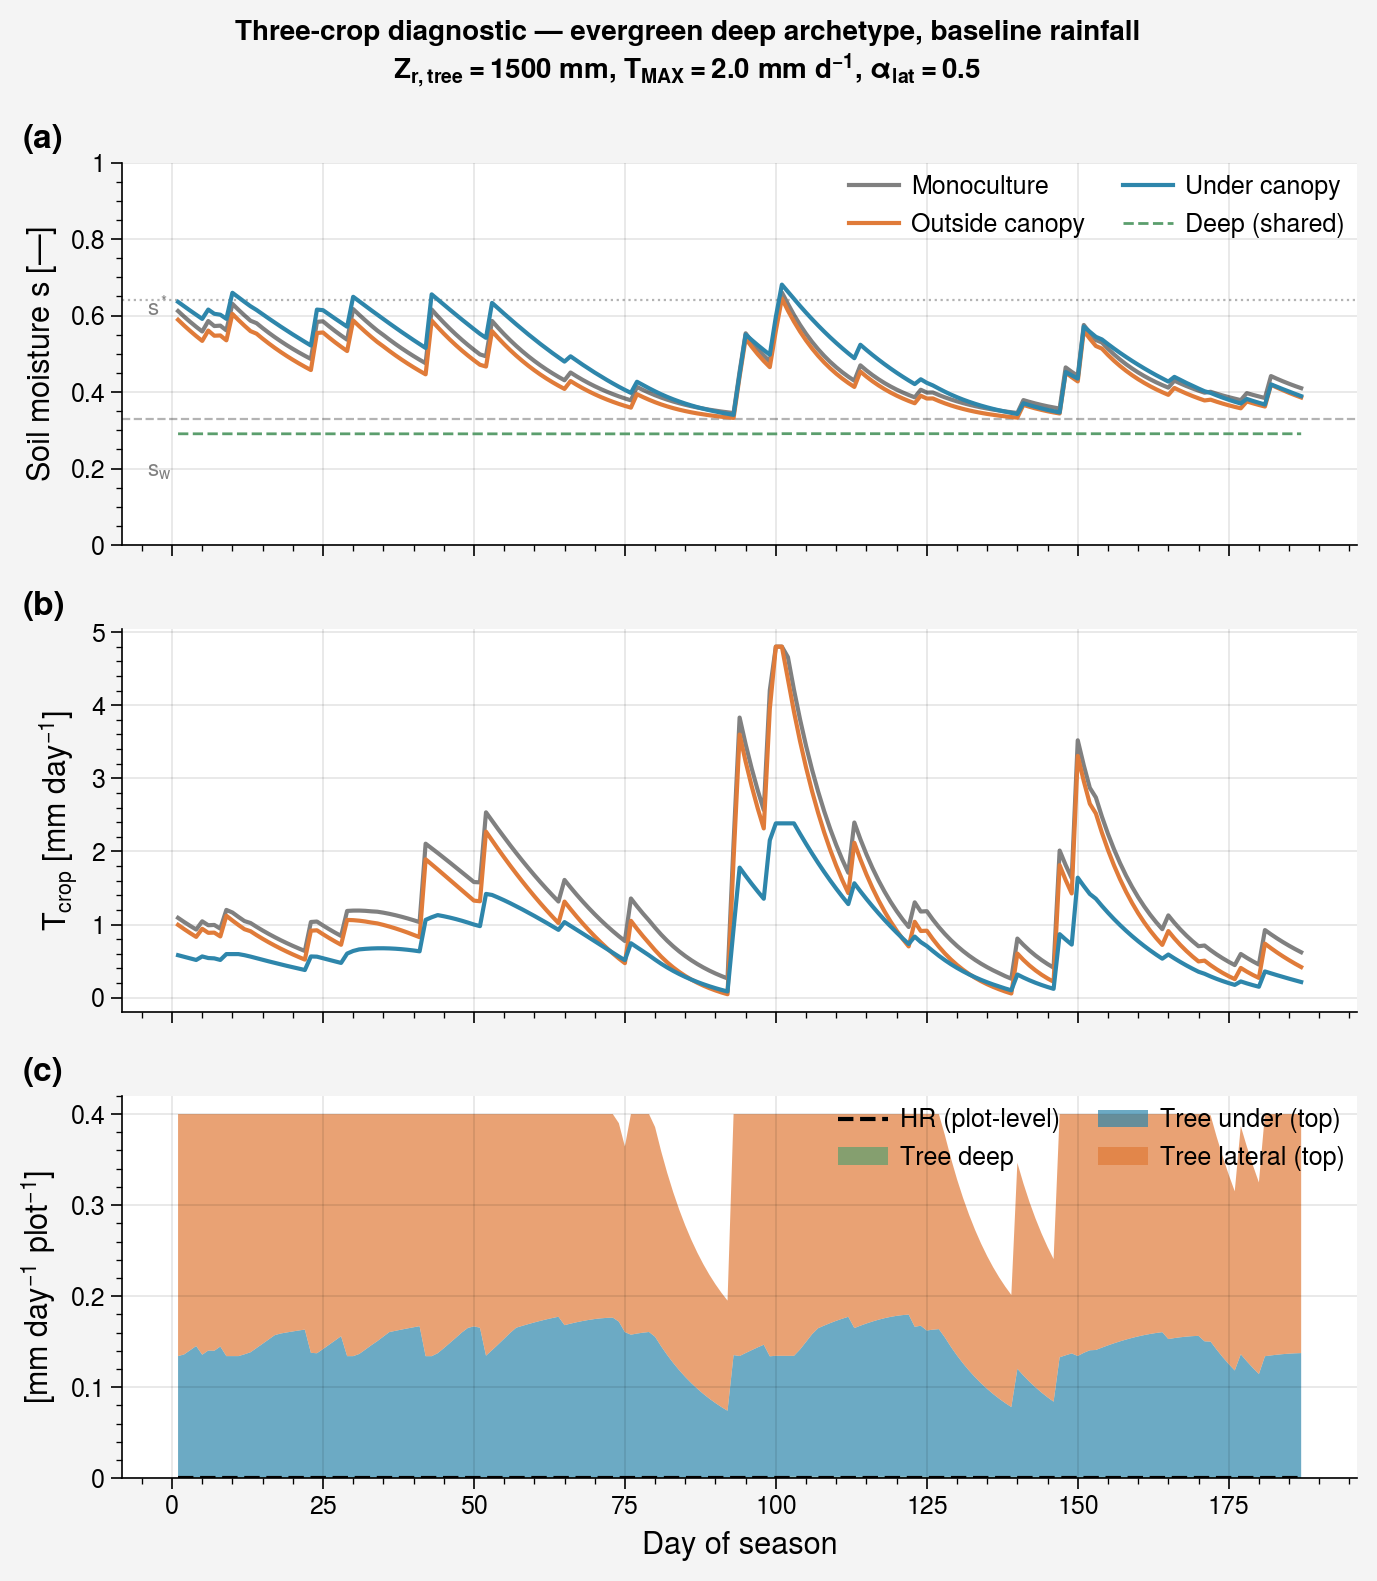

Seasonal rainfall: 512 mm
  monoculture         RF=512 mm   yield=1433 kg/acre
  under-canopy        RF=512 mm   yield=2082 kg/acre
  outside             RF=512 mm   yield=318 kg/acre


In [11]:
# ── Single-season diagnostic ─────────────────────────────────────────────────
np.random.seed(42)
_climate_diag = Climate(**CLIMATE_KWARGS)

_tree_primary = dict(
    Zr=1500, T_MAX=2.0, sw_MPa=-4.0, s_star_MPa=-0.1,
    kc=1.0, canopy_cover=0.2, leaf_fraction=1.0,
)

_crop_3, _out_u, _out_o, _out_tree = run_one_season_three(
    Soil, Crop, _climate_diag, n_spinup=5, tree_params=_tree_primary,
)
_crop_m, _out_m = run_one_season(
    CropModel, Soil, Crop, _climate_diag, n_spinup=0,
)

# CropModel uses "s" and "T"; ThreeCropModel uses "s_top" and "T_crop".
_s_m_col  = "s_top" if "s_top" in _out_m.columns else "s"
_T_m_col  = "T_crop" if "T_crop" in _out_m.columns else "T"

# Mask to crop season only (dos > 0)
_mask  = _out_u["dos"].values > 0
_days  = _out_u["dos"].values[_mask]
_s_m   = _out_m[_s_m_col].values[_mask]
_s_u   = _out_u["s_top"].values[_mask]
_s_o   = _out_o["s_top"].values[_mask]

_soil_ref = Soil(texture="loam")
_sw_crop  = Crop(soil=_soil_ref).sw
_s_star_c = Crop(soil=_soil_ref).s_star

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)

# ── Panel (a): Soil moisture traces ──────────────────────────────────────────
ax = axes[0]
ax.axhline(_sw_crop,  color="0.7", lw=0.8, ls="--", zorder=0, label="$s_w$")
ax.axhline(_s_star_c, color="0.7", lw=0.8, ls=":",  zorder=0, label="$s^*$")
ax.plot(_days, _s_m, color="0.5",     lw=1.5, label="Monoculture",     zorder=1)
ax.plot(_days, _s_o, color="#E07B39", lw=1.5, label="Outside canopy",  zorder=2)
ax.plot(_days, _s_u, color="#2E86AB", lw=1.5, label="Under canopy",    zorder=3)
ax.set_ylabel("Soil moisture $s$ [—]")
ax.set_ylim(0, 1)
ax.legend(loc="upper right", ncol=2)
pub_label(ax, "(a)")
despine(ax)

# ── Panel (b): Crop transpiration ─────────────────────────────────────────────
ax = axes[1]
ax.plot(_days, _out_m[_T_m_col].values[_mask],  color="0.5",     lw=1.5, label="Monoculture")
ax.plot(_days, _out_o["T_crop"].values[_mask],   color="#E07B39", lw=1.5, label="Outside canopy")
ax.plot(_days, _out_u["T_crop"].values[_mask],   color="#2E86AB", lw=1.5, label="Under canopy")
ax.set_ylabel("$T_{crop}$ [mm day$^{-1}$]")
pub_label(ax, "(b)")
despine(ax)

# ── Panel (c): Tree water use and HR ──────────────────────────────────────────
ax = axes[2]
ax.stackplot(
    _days,
    _out_tree["T_tree_deep"].values[_mask],
    _out_tree["T_tree_under"].values[_mask],
    _out_tree["T_tree_lateral"].values[_mask],
    labels=["Tree deep", "Tree under (top)", "Tree lateral (top)"],
    colors=["#5B9E6D", "#2E86AB", "#E07B39"],
    alpha=0.7,
)
ax.set_ylabel("[mm day$^{-1}$ plot$^{-1}$]")
ax.set_xlabel("Day of season")
ax.legend(loc="upper right", ncol=2)
pub_label(ax, "(c)")
despine(ax)

fig.suptitle(
    "Three-crop diagnostic — evergreen deep archetype, baseline rainfall\n"
    r"$Z_{r,tree}=1500$ mm, $T_{MAX}=2.0$ mm d$^{-1}$, $\alpha_{lat}=0.5$",
    fontsize=10,
)
fig.tight_layout()
fig.savefig("output/threecrop_diagnostic.png")
plt.show()

# ── Yield summary ─────────────────────────────────────────────────────────────
print(f"Seasonal rainfall: {_out_m['R'].sum():.0f} mm")
for label, crop_obj, out in [
    ("monoculture",   _crop_m, _out_m),
    ("under-canopy",  _crop_3, _out_u),
    ("outside",       _crop_3, _out_o),
]:
    _, _, y, rf = season_metrics(crop_obj, out, 180)
    print(f"  {label:18s}  RF={rf:.0f} mm   yield={y:.0f} kg/acre")


## Monte Carlo: yield CDFs — three crops × three rainfall regimes

300 seasons per regime. Overlaid CDFs for under-canopy, outside-canopy, and monoculture.

Mechanistic decompositions:
- **Outside − Mono** = pure root competition (no shade confound)
- **Under − Outside** = pure demand-side facilitation (shade benefit minus shared competition)
- **Under − Mono** = net agroforestry effect for under-canopy crop

In [12]:
# ── Rainfall regime definitions (CLAUDE.md §2e) ──────────────────────────────
_ALPHA_BASE  = _alpha_cetrad   # CETRAD OL JOGI FARM baseline mean storm depth [mm]
_LAMBDA_BASE = _lambda_cetrad  # CETRAD baseline storm frequency [day^-1]

def _make_climate(alpha_scale=1.0, lambda_scale=1.0):
    """Build a Climate with uniformly scaled rainfall parameters."""
    return Climate(
        alpha_r  =[a * alpha_scale  for a in _ALPHA_BASE],
        lambda_r =[l * lambda_scale for l in _LAMBDA_BASE],
    )


def simulate_three_crops_regime(n_sims, *, climate_factory,
                                 lgp=180, texture="loam", seed=123,
                                 tree_params=None, alpha_lateral=0.5, n_spinup=5):
    """
    Like simulate_three_crops but accepts a climate_factory callable → Climate.
    Shares the same paired-climate design: mono and ThreeCropModel get the same
    stochastic draw per iteration.
    """
    if tree_params is None:
        tree_params = dict(
            Zr=1500, T_MAX=2.0, sw_MPa=-4.0, s_star_MPa=-0.1,
            kc=1.0, canopy_cover=0.2, leaf_fraction=1.0,
        )
    rng = np.random.default_rng(seed)
    rows_under, rows_outside, rows_mono = [], [], []

    for i in range(n_sims):
        np.random.seed(rng.integers(0, 2**32 - 1, dtype=np.uint32).item())
        climate = climate_factory()

        crop_m, out_m = run_one_season(CropModel, Soil, Crop, climate,
                                       texture=texture, lgp=lgp, n_spinup=n_spinup)
        a, d, y, rf = season_metrics(crop_m, out_m, lgp)
        rows_mono.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))

        crop_t, out_u, out_o, _ = run_one_season_three(
            Soil, Crop, climate, texture=texture, lgp=lgp, n_spinup=n_spinup,
            tree_params=tree_params, alpha_lateral=alpha_lateral,
        )
        a, d, y, rf = season_metrics(crop_t, out_u, lgp)
        rows_under.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        a, d, y, rf = season_metrics(crop_t, out_o, lgp)
        rows_outside.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))

    return pd.DataFrame(rows_under), pd.DataFrame(rows_outside), pd.DataFrame(rows_mono)


# ── Run 300 × 3 regimes ───────────────────────────────────────────────────────
N_SIMS = 300
REGIMES = [
    dict(label="Few intense\n(1.5× depth, 0.67× freq)",
         alpha_scale=1.5, lambda_scale=0.67),
    dict(label="Baseline",
         alpha_scale=1.0, lambda_scale=1.0),
    dict(label="Many small\n(0.67× depth, 1.5× freq)",
         alpha_scale=0.67, lambda_scale=1.5),
]

_tree_mc = dict(
    Zr=1500, T_MAX=2.0, sw_MPa=-4.0, s_star_MPa=-0.1,
    kc=1.0, canopy_cover=0.2, leaf_fraction=1.0,
)

results = []
for reg in REGIMES:
    factory = lambda a=reg["alpha_scale"], l=reg["lambda_scale"]: _make_climate(a, l)
    df_u, df_o, df_m = simulate_three_crops_regime(
        N_SIMS, climate_factory=factory, seed=123, n_spinup=5,
        tree_params=_tree_mc,
    )
    results.append((df_u, df_o, df_m))
    print(f"{reg['label'].split(chr(10))[0]:30s}  "
          f"under={df_u.Yield.mean():.0f}  "
          f"outside={df_o.Yield.mean():.0f}  "
          f"mono={df_m.Yield.mean():.0f}  kg/acre")


Few intense                     under=1361  outside=850  mono=1000  kg/acre


Baseline                        under=1146  outside=724  mono=942  kg/acre


Many small                      under=765  outside=471  mono=761  kg/acre


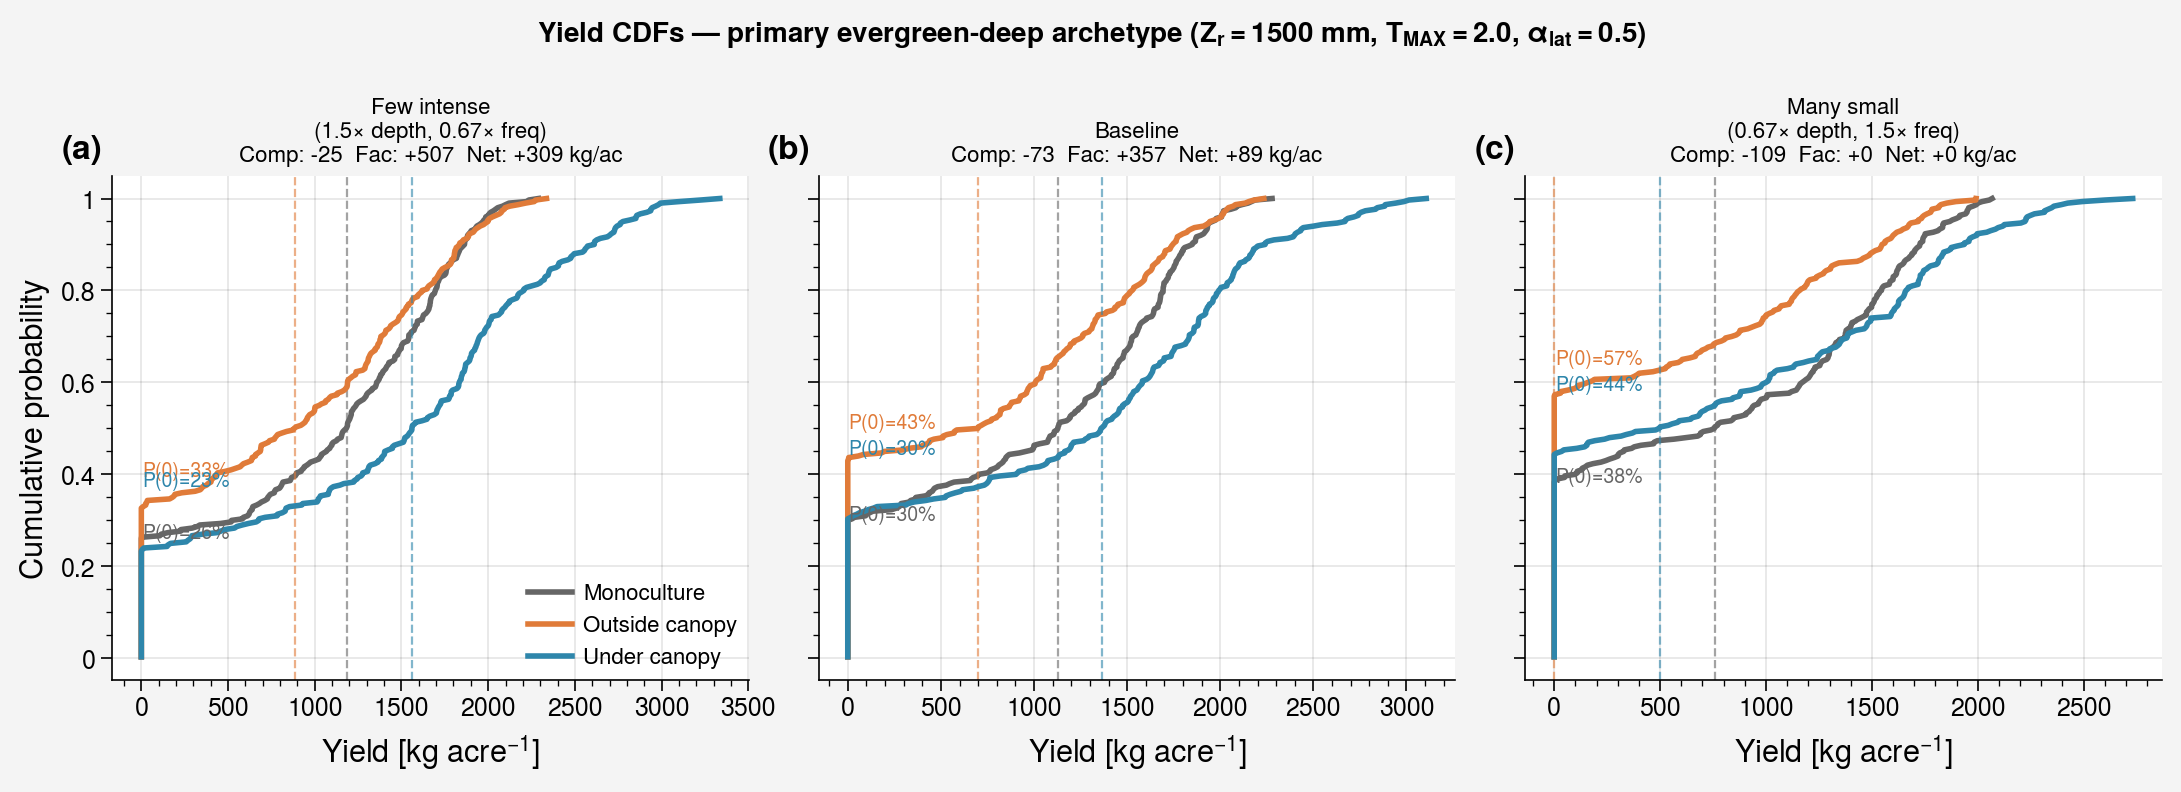

In [13]:
# ── Yield CDF figure — three crops × three rainfall regimes ──────────────────
_COLORS = {
    "Monoculture":    "0.4",
    "Outside canopy": "#E07B39",
    "Under canopy":   "#2E86AB",
}

fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)

for ax, reg, (df_u, df_o, df_m) in zip(axes, REGIMES, results):
    for label, df, col in [
        ("Monoculture",    df_m, _COLORS["Monoculture"]),
        ("Outside canopy", df_o, _COLORS["Outside canopy"]),
        ("Under canopy",   df_u, _COLORS["Under canopy"]),
    ]:
        vals = np.sort(df["Yield"].values)
        cdf  = np.arange(1, len(vals) + 1) / len(vals)
        ax.plot(vals, cdf, color=col, lw=2, label=label)
        ax.axvline(np.median(vals), color=col, lw=0.8, ls="--", alpha=0.6)

    # P(zero yield) annotation
    y_top = 1.0
    for df, col, dy in [(df_m, _COLORS["Monoculture"], 0.0),
                        (df_o, _COLORS["Outside canopy"], 0.07),
                        (df_u, _COLORS["Under canopy"], 0.14)]:
        p0 = (df["Yield"] == 0).mean()
        if p0 > 0:
            ax.annotate(f"P(0)={p0:.0%}", xy=(0, p0),
                        xytext=(5, p0 + dy),
                        fontsize=7, color=col)

    # Mechanistic decomposition labels (median ΔYield)
    dY_comp = np.median(df_o["Yield"].values - df_m["Yield"].values)
    dY_fac  = np.median(df_u["Yield"].values - df_o["Yield"].values)
    dY_net  = np.median(df_u["Yield"].values - df_m["Yield"].values)
    ax.set_title(
        reg["label"] + "\n"
        + f"Comp: {dY_comp:+.0f}  Fac: {dY_fac:+.0f}  Net: {dY_net:+.0f} kg/ac",
        fontsize=8,
    )
    ax.set_xlabel("Yield [kg acre$^{-1}$]")
    despine(ax)

axes[0].set_ylabel("Cumulative probability")
axes[0].legend(loc="lower right", fontsize=8)

for ax, lbl in zip(axes, ["(a)", "(b)", "(c)"]):
    pub_label(ax, lbl)

fig.suptitle(
    r"Yield CDFs — primary evergreen-deep archetype ($Z_r=1500$ mm, "
    r"$T_{MAX}=2.0$, $\alpha_{lat}=0.5$)",
    fontsize=10,
)
fig.tight_layout()
fig.savefig("output/threecrop_yield_cdfs.png")
plt.show()


## T_MAX sweep: competition–facilitation transition

In [14]:
# ── T_MAX sweep: find competition→facilitation transition ────────────────────
# Evergreen deep archetype (Zr=1500, cc=0.2, leaf_fraction=1.0)
# Sweeps T_MAX from 1.0 to 4.0 across all three rainfall regimes.
# Each cell: 100 paired simulations (mono + under + outside, same climate draw).

TMAX_VALS = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
N_SWEEP   = 100

sweep_results = []  # [{label, rows: [{T_MAX, dY_net, dY_comp, dY_fac}, ...]}]

for reg in REGIMES:
    label   = reg["label"].split("\n")[0]
    factory = lambda a=reg["alpha_scale"], l=reg["lambda_scale"]: _make_climate(a, l)
    rows    = []
    for tmax in TMAX_VALS:
        tree_p = dict(Zr=1500, T_MAX=tmax, sw_MPa=-4.0, s_star_MPa=-0.1,
                      kc=1.0, canopy_cover=0.2, leaf_fraction=1.0)
        df_u, df_o, df_m = simulate_three_crops_regime(
            N_SWEEP, climate_factory=factory, seed=123, n_spinup=5,
            tree_params=tree_p,
        )
        dY_net  = (df_u.Yield - df_m.Yield).mean()   # Under − Mono  (net effect)
        dY_comp = (df_o.Yield - df_m.Yield).mean()   # Outside − Mono (competition)
        dY_fac  = (df_u.Yield - df_o.Yield).mean()   # Under − Outside (shade)
        rows.append(dict(T_MAX=tmax, dY_net=dY_net, dY_comp=dY_comp, dY_fac=dY_fac))
        print(f"  {label:25s}  T_MAX={tmax:.1f}  "
              f"net={dY_net:+.0f}  comp={dY_comp:+.0f}  shade={dY_fac:+.0f}")
    sweep_results.append(dict(label=reg["label"], rows=rows))

print("Sweep complete.")

  Few intense                T_MAX=1.0  net=+890  comp=+32  shade=+858


  Few intense                T_MAX=1.5  net=+653  comp=-72  shade=+726


  Few intense                T_MAX=2.0  net=+438  comp=-174  shade=+612


  Few intense                T_MAX=2.5  net=+232  comp=-233  shade=+466


  Few intense                T_MAX=3.0  net=+8  comp=-288  shade=+296


...

  Many small                 T_MAX=2.0  net=-4  comp=-296  shade=+292


  Many small                 T_MAX=2.5  net=-152  comp=-368  shade=+216


  Many small                 T_MAX=3.0  net=-312  comp=-465  shade=+153


  Many small                 T_MAX=3.5  net=-458  comp=-520  shade=+63


  Many small                 T_MAX=4.0  net=-522  comp=-553  shade=+31
Sweep complete.


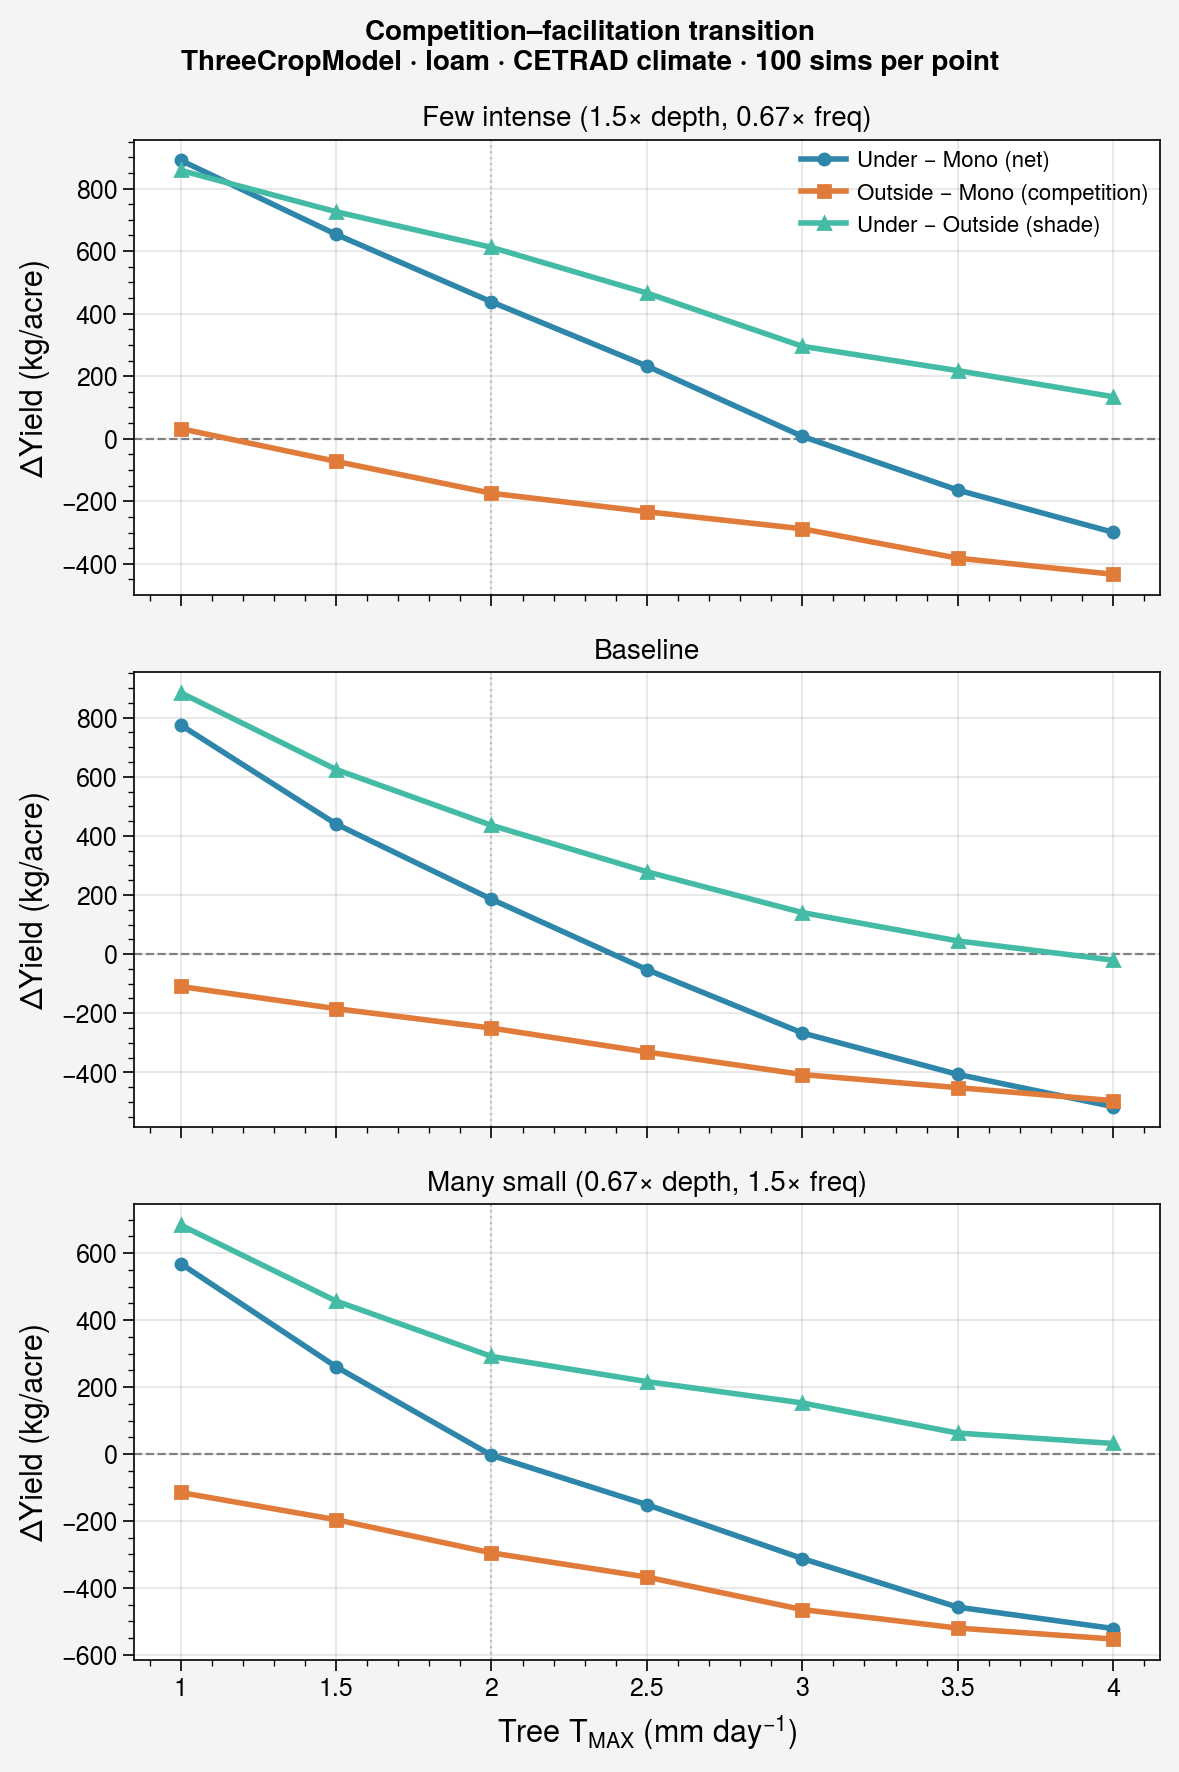

In [15]:
# ── T_MAX sweep figure ───────────────────────────────────────────────────────
_C_NET  = "#2E86AB"   # blue   — Under − Mono  (net agroforestry effect)
_C_COMP = "#E07B39"   # orange — Outside − Mono (root competition only)
_C_FAC  = "#44BBA4"   # teal   — Under − Outside (shade facilitation)

fig, axes = plt.subplots(3, 1, figsize=(6, 9), sharex=True)

for ax, res in zip(axes, sweep_results):
    rows  = res["rows"]
    tvals = [r["T_MAX"]  for r in rows]
    nets  = [r["dY_net"] for r in rows]
    comps = [r["dY_comp"] for r in rows]
    facs  = [r["dY_fac"]  for r in rows]

    ax.axhline(0, color="0.5", lw=0.8, ls="--")
    ax.axvline(2.0, color="0.75", lw=0.8, ls=":")  # reference: current default

    ax.plot(tvals, nets,  color=_C_NET,  lw=2, marker="o", ms=4, label="Under − Mono (net)")
    ax.plot(tvals, comps, color=_C_COMP, lw=2, marker="s", ms=4, label="Outside − Mono (competition)")
    ax.plot(tvals, facs,  color=_C_FAC,  lw=2, marker="^", ms=4, label="Under − Outside (shade)")

    ax.set_ylabel("ΔYield (kg/acre)")
    ax.set_title(res["label"].replace("\n", " "), fontsize=10)
    if ax is axes[0]:
        ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Tree $T_{\\mathrm{MAX}}$ (mm day$^{-1}$)")
fig.suptitle(
    "Competition–facilitation transition\n"
    "ThreeCropModel · loam · CETRAD climate · 100 sims per point",
    fontsize=10,
)
fig.tight_layout()
plt.show()

## Trait surface: leaf fraction × root depth (ThreeCropModel)

Sweeps `leaf_fraction` (0 → 1) and `Zr_tree` (600 → 2000 mm) at baseline CETRAD rainfall.
N = 150 paired seasons per cell. T_MAX = 2.0, canopy_cover = 0.2 fixed throughout.

In [16]:
# ── Trait surface sweep (leaf_fraction × Zr, baseline rainfall) ───────────────
LF_VALS  = [0.0, 0.25, 0.5, 0.75, 1.0]
ZR_VALS  = [600, 800, 1000, 1200, 1500, 2000]
N_TRAIT  = 150
_factory_base = lambda: _make_climate(1.0, 1.0)

trait_surface = {}   # (lf, zr) -> dict(dY_under, dY_outside)

for lf in LF_VALS:
    for zr in ZR_VALS:
        tree_p = dict(Zr=zr, T_MAX=2.0, sw_MPa=-4.0, s_star_MPa=-0.1,
                      kc=1.0, canopy_cover=0.2, leaf_fraction=lf)
        df_u, df_o, df_m = simulate_three_crops_regime(
            N_TRAIT, climate_factory=_factory_base, seed=42, n_spinup=5,
            tree_params=tree_p,
        )
        trait_surface[(lf, zr)] = dict(
            dY_under   = (df_u.Yield - df_m.Yield).median(),
            dY_outside = (df_o.Yield - df_m.Yield).median(),
        )
        print(f"lf={lf:.2f}  Zr={zr:4d}  "
              f"under={trait_surface[(lf,zr)]['dY_under']:+.0f}  "
              f"outside={trait_surface[(lf,zr)]['dY_outside']:+.0f}  kg/acre")

print('Trait surface sweep complete.')


lf=0.00  Zr= 600  under=+43  outside=+0  kg/acre


lf=0.00  Zr= 800  under=+26  outside=+0  kg/acre


lf=0.00  Zr=1000  under=+21  outside=+0  kg/acre


lf=0.00  Zr=1200  under=+19  outside=+0  kg/acre


lf=0.00  Zr=1500  under=+11  outside=+0  kg/acre


...

lf=1.00  Zr= 800  under=+161  outside=-28  kg/acre


lf=1.00  Zr=1000  under=+150  outside=-32  kg/acre


lf=1.00  Zr=1200  under=+147  outside=-41  kg/acre


lf=1.00  Zr=1500  under=+147  outside=-52  kg/acre


lf=1.00  Zr=2000  under=+142  outside=-58  kg/acre
Trait surface sweep complete.


/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 8201 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 8201 missing from current font.
  font.set_text(s, 0, flags=flags)


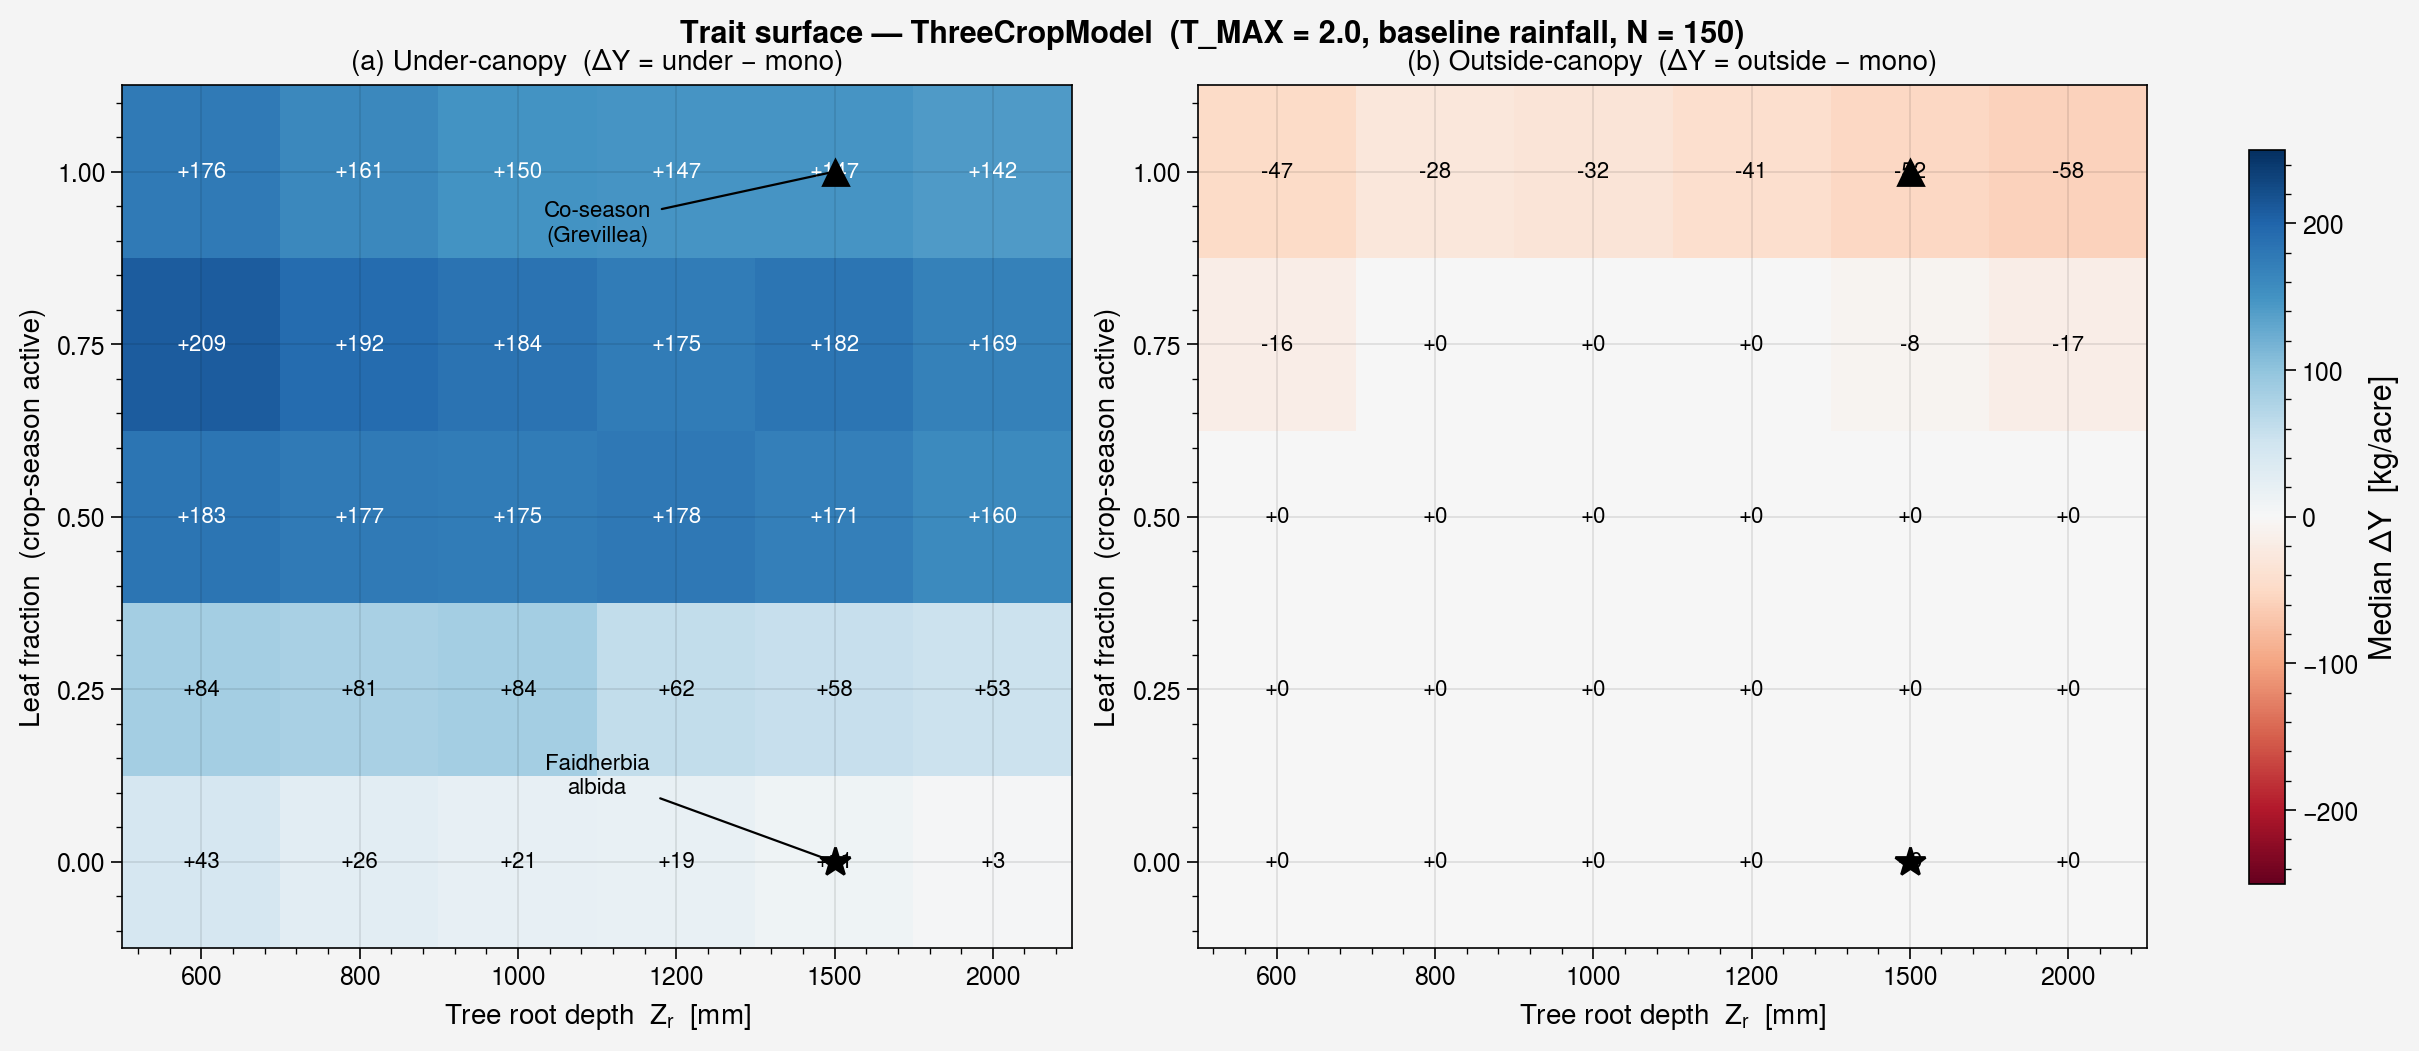

Saved output/fig_trait_surface_threecrop.png


In [17]:
# ── Trait surface figure: under-canopy and outside-canopy ΔY ────────────
import matplotlib.colors as mcolors

grid_under   = np.array([[trait_surface[(lf, zr)]['dY_under']   for zr in ZR_VALS]
                          for lf in LF_VALS])
grid_outside = np.array([[trait_surface[(lf, zr)]['dY_outside'] for zr in ZR_VALS]
                          for lf in LF_VALS])

vmax = max(abs(grid_under).max(), abs(grid_outside).max())
vmax = np.ceil(vmax / 50) * 50
cmap_div = plt.cm.RdBu
norm_div = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
panel_titles = [
    '(a) Under-canopy  (ΔY = under − mono)',
    '(b) Outside-canopy  (ΔY = outside − mono)',
]
grids = [grid_under, grid_outside]

for ax, grid, title in zip(axes, grids, panel_titles):
    im = ax.imshow(grid, aspect='auto', cmap=cmap_div, norm=norm_div,
                   origin='lower', interpolation='nearest')
    ax.set_xticks(range(len(ZR_VALS)))
    ax.set_xticklabels([str(z) for z in ZR_VALS], fontsize=9)
    ax.set_yticks(range(len(LF_VALS)))
    ax.set_yticklabels([f'{lf:.2f}' for lf in LF_VALS])
    ax.set_xlabel('Tree root depth  $Z_r$  [mm]', fontsize=10)
    ax.set_ylabel('Leaf fraction  (crop-season active)', fontsize=10)
    ax.set_title(title, fontsize=10, pad=6)
    for i, lf in enumerate(LF_VALS):
        for j, zr in enumerate(ZR_VALS):
            val = grid[i, j]
            fc = 'white' if abs(val) > vmax * 0.45 else 'black'
            ax.text(j, i, f'{val:+.0f}', ha='center', va='center', fontsize=8, color=fc)
    ax.plot(ZR_VALS.index(1500), LF_VALS.index(0.0), 'k*',  ms=11, zorder=5)
    ax.plot(ZR_VALS.index(1500), LF_VALS.index(1.0), 'k^',  ms=9,  zorder=5)

axes[0].annotate('Faidherbia\nalbida',
                 xy=(ZR_VALS.index(1500), LF_VALS.index(0.0)),
                 xytext=(ZR_VALS.index(1500) - 1.5, LF_VALS.index(0.0) + 0.4),
                 fontsize=8, ha='center',
                 arrowprops=dict(arrowstyle='-', color='black', lw=0.8))
axes[0].annotate('Co-season\n(Grevillea)',
                 xy=(ZR_VALS.index(1500), LF_VALS.index(1.0)),
                 xytext=(ZR_VALS.index(1500) - 1.5, LF_VALS.index(1.0) - 0.4),
                 fontsize=8, ha='center',
                 arrowprops=dict(arrowstyle='-', color='black', lw=0.8))

fig.colorbar(im, ax=axes.ravel().tolist(),
             label='Median ΔY  [kg/acre]', shrink=0.85)
fig.suptitle(
    'Trait surface — ThreeCropModel  (T_MAX = 2.0, baseline rainfall, N = 150)',
    fontsize=11, y=1.02)

plt.savefig('output/fig_trait_surface_threecrop.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved output/fig_trait_surface_threecrop.png')


## Trait surface × rainfall regime (ThreeCropModel)

Same leaf_fraction × Zr grid repeated for all three rainfall regimes.
Shows under-canopy ΔY only. N = 100 per cell, T_MAX = 2.0.
Primary archetype (Zr=1500, leaf_frac=1.0) marked with a star.

In [18]:
# ── Trait surface × 3 rainfall regimes sweep ────────────────────────────
N_REGIME_TRAIT = 100

trait_regime = {}   # (regime_idx, lf, zr) -> dict(dY_under, dY_outside)

for ri, reg in enumerate(REGIMES):
    factory = (lambda a=reg['alpha_scale'], l=reg['lambda_scale']:
               _make_climate(a, l))
    for lf in LF_VALS:
        for zr in ZR_VALS:
            tree_p = dict(Zr=zr, T_MAX=2.0, sw_MPa=-4.0, s_star_MPa=-0.1,
                          kc=1.0, canopy_cover=0.2, leaf_fraction=lf)
            df_u, df_o, df_m = simulate_three_crops_regime(
                N_REGIME_TRAIT, climate_factory=factory, seed=42, n_spinup=5,
                tree_params=tree_p,
            )
            trait_regime[(ri, lf, zr)] = dict(
                dY_under   = (df_u.Yield - df_m.Yield).median(),
                dY_outside = (df_o.Yield - df_m.Yield).median(),
            )
    label = reg['label'].replace('\n', ' ')
    print(f'Regime {ri+1}/3 ({label}) complete.')

print('Regime sweep complete.')


Regime 1/3 (Few intense (1.5× depth, 0.67× freq)) complete.


Regime 2/3 (Baseline) complete.


Regime 3/3 (Many small (0.67× depth, 1.5× freq)) complete.
Regime sweep complete.


/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 8201 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 8201 missing from current font.
  font.set_text(s, 0, flags=flags)


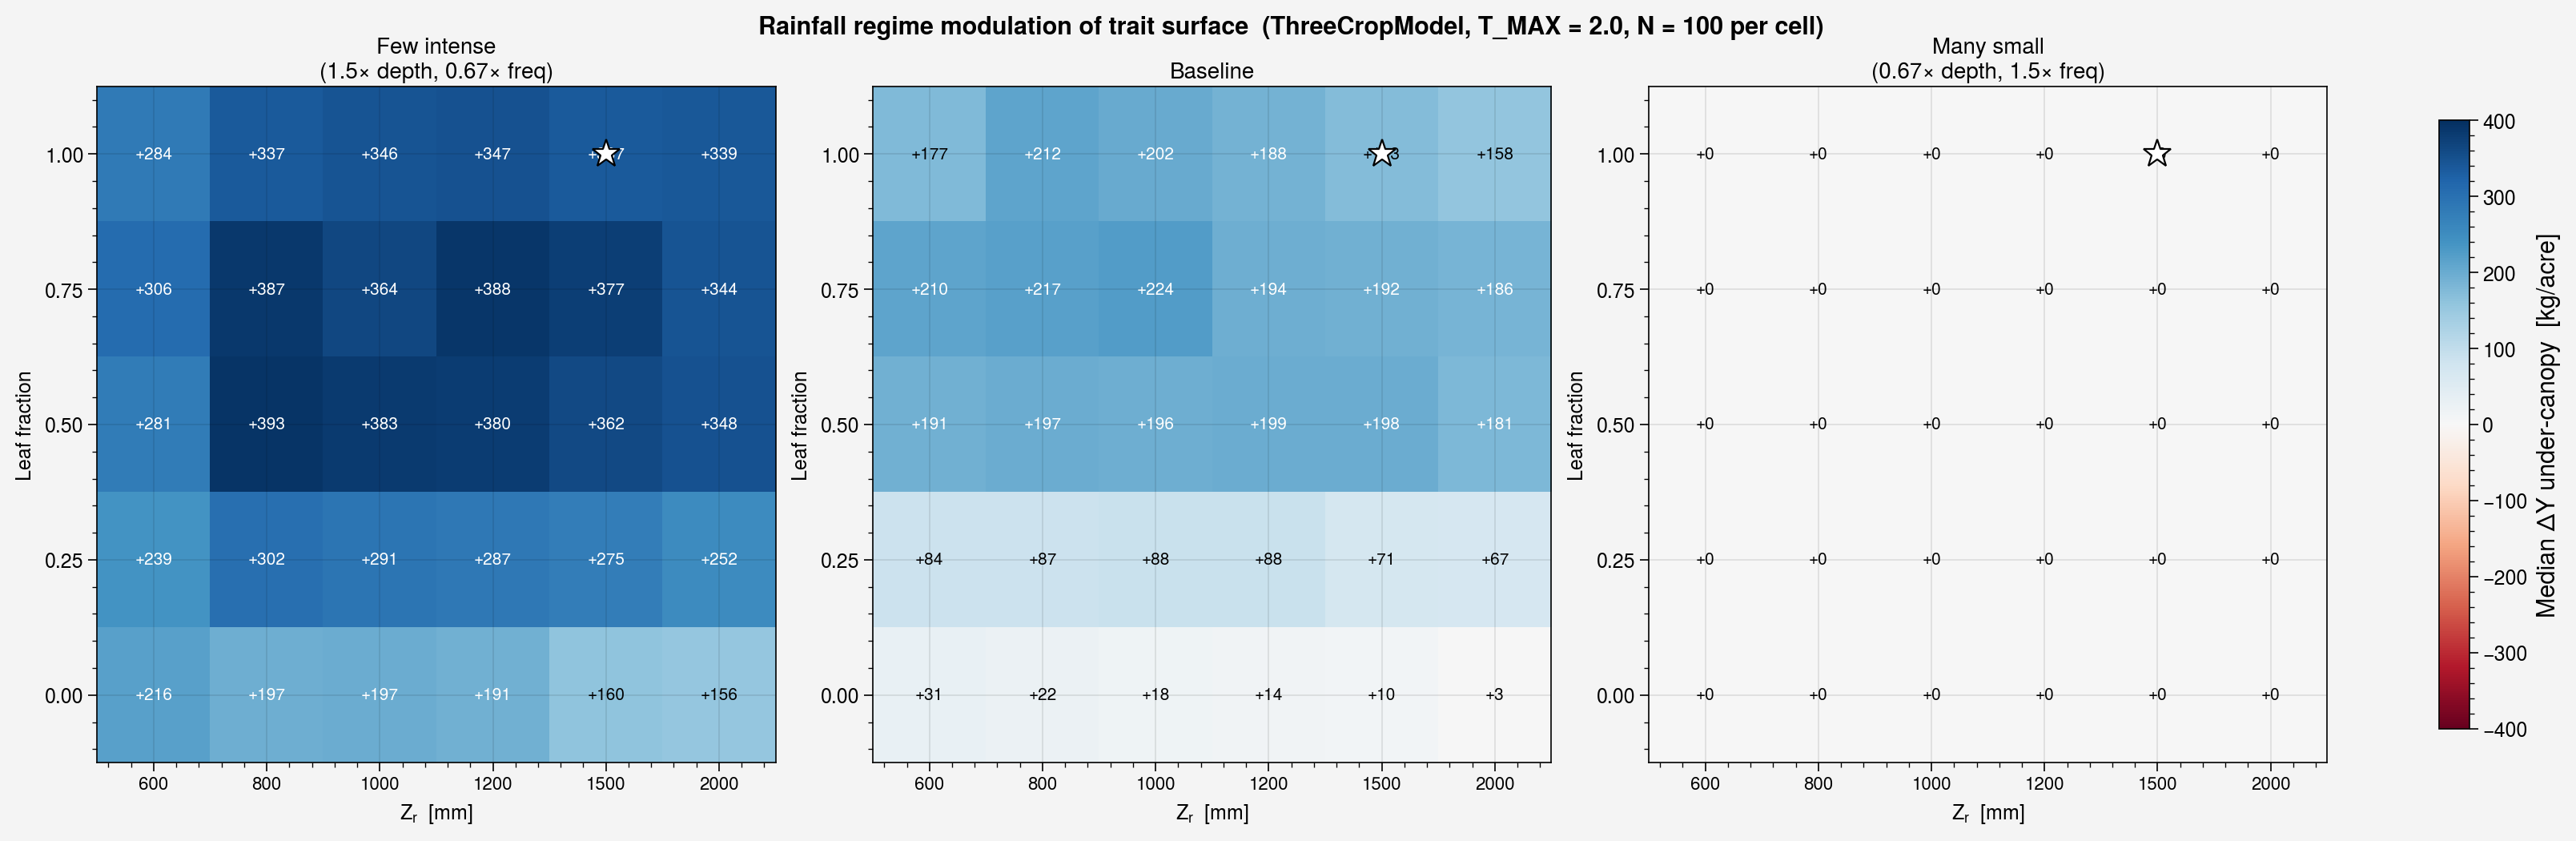

Saved output/fig_trait_regime_threecrop.png


In [19]:
# ── Trait surface × rainfall regimes figure (under-canopy ΔY) ───────────────
grids_reg = [
    np.array([[trait_regime[(ri, lf, zr)]['dY_under']
               for zr in ZR_VALS]
              for lf in LF_VALS])
    for ri in range(3)
]

vmax_reg = max(abs(g).max() for g in grids_reg)
vmax_reg = np.ceil(vmax_reg / 50) * 50
norm_reg = mcolors.TwoSlopeNorm(vmin=-vmax_reg, vcenter=0, vmax=vmax_reg)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, grid, reg in zip(axes, grids_reg, REGIMES):
    im = ax.imshow(grid, aspect='auto', cmap=cmap_div, norm=norm_reg,
                   origin='lower', interpolation='nearest')
    ax.set_xticks(range(len(ZR_VALS)))
    ax.set_xticklabels([str(z) for z in ZR_VALS], fontsize=8)
    ax.set_yticks(range(len(LF_VALS)))
    ax.set_yticklabels([f'{lf:.2f}' for lf in LF_VALS], fontsize=9)
    ax.set_xlabel('$Z_r$  [mm]', fontsize=9)
    ax.set_ylabel('Leaf fraction', fontsize=9)
    ax.set_title(reg['label'], fontsize=10, pad=4)
    for i, lf in enumerate(LF_VALS):
        for j, zr in enumerate(ZR_VALS):
            val = grid[i, j]
            fc = 'white' if abs(val) > vmax_reg * 0.45 else 'black'
            ax.text(j, i, f'{val:+.0f}', ha='center', va='center',
                    fontsize=7.5, color=fc)
    ax.plot(ZR_VALS.index(1500), LF_VALS.index(1.0), 'w*',
            ms=13, markeredgecolor='k', markeredgewidth=0.8, zorder=5)

fig.colorbar(im, ax=axes.ravel().tolist(),
             label='Median ΔY under-canopy  [kg/acre]', shrink=0.9)
fig.suptitle(
    'Rainfall regime modulation of trait surface  '
    '(ThreeCropModel, T_MAX = 2.0, N = 100 per cell)',
    fontsize=11, y=1.02)

plt.savefig('output/fig_trait_regime_threecrop.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved output/fig_trait_regime_threecrop.png')


## Yield variance and P(near-zero yield) — under-canopy vs monoculture

Uses `results` from the Monte Carlo section above (N = 300 per regime, primary archetype:
Zr=1500, T_MAX=2.0, leaf_frac=1.0). Quantifies whether a co-season leafed tree reduces
yield variability and the frequency of crop failure across rainfall regimes.

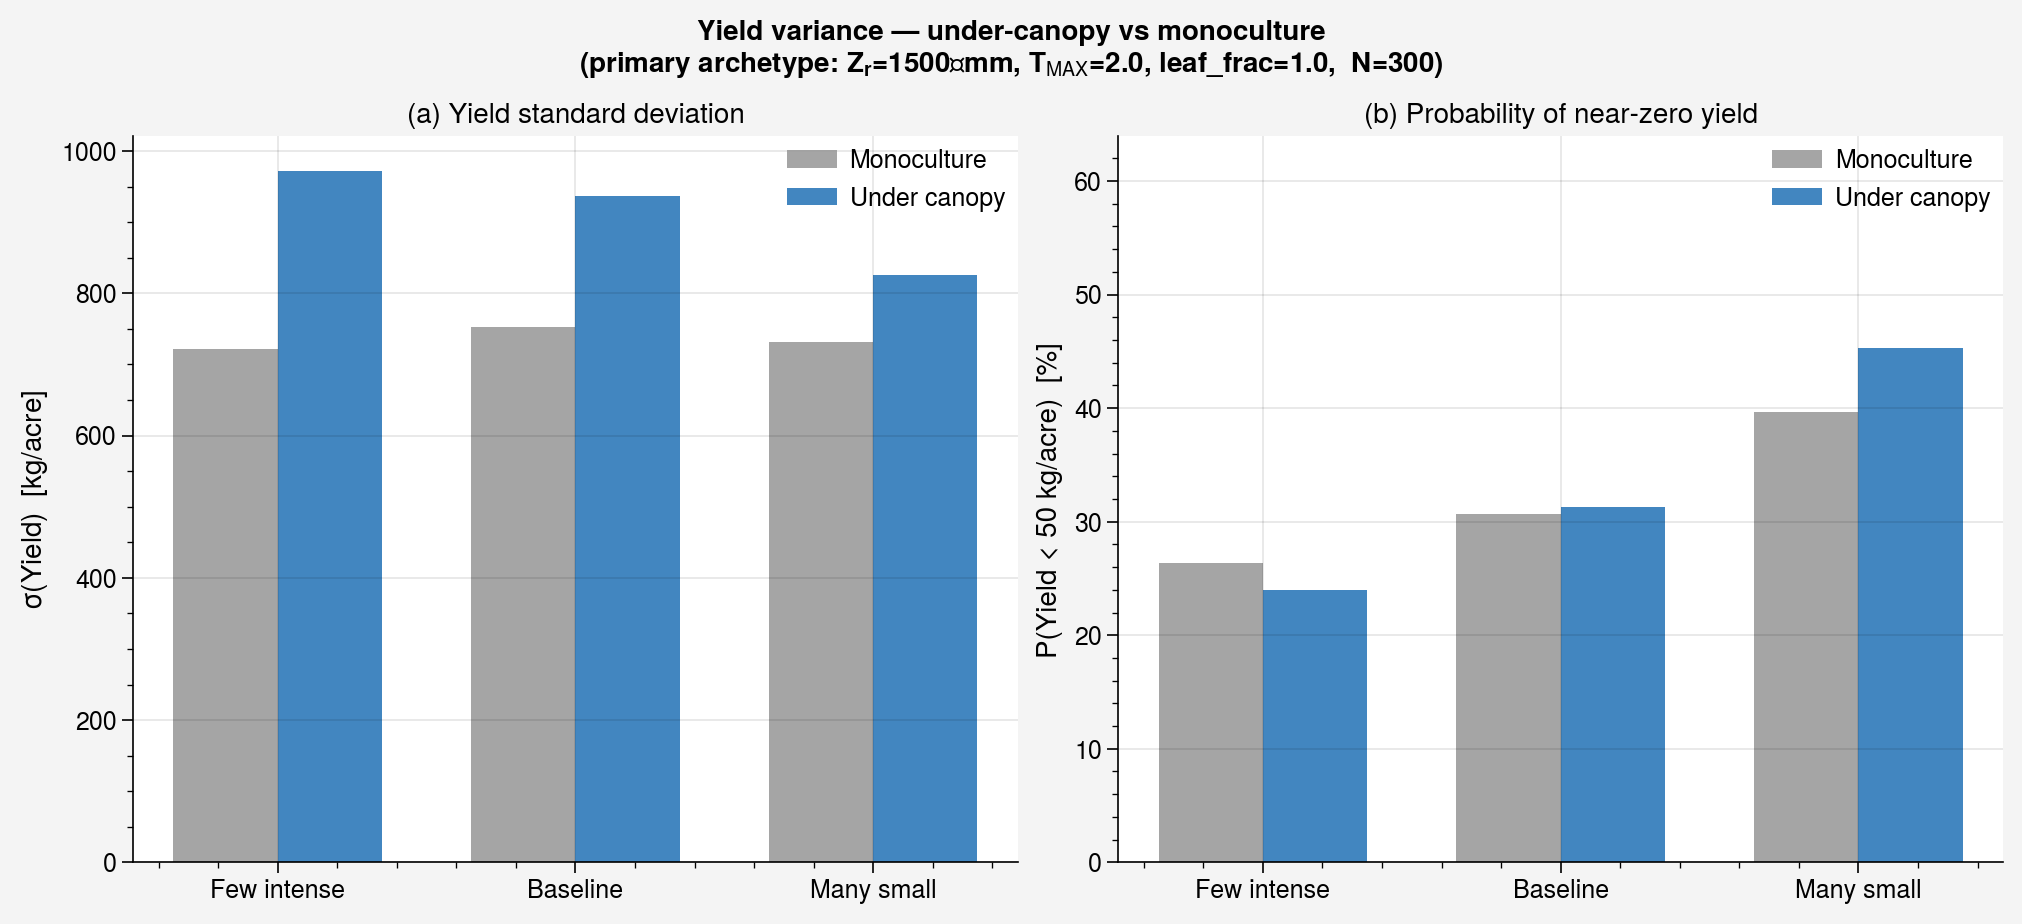

Saved output/fig_variance_threecrop.png

Summary:
  Few intense                sigma: mono=721  under=972   P(0): mono=26.3%  under=24.0%
  Baseline                   sigma: mono=753  under=937   P(0): mono=30.7%  under=31.3%
  Many small                 sigma: mono=732  under=826   P(0): mono=39.7%  under=45.3%


In [20]:
# ── Yield variance & P(near-zero yield) ───────────────────────────────────────
# results = [(df_under, df_outside, df_mono), ...] for each of the 3 regimes.
# P(near-zero) = P(Yield < ZERO_THRESHOLD).

ZERO_THRESHOLD = 50   # kg/acre

regime_labels_short = [r['label'].split('\n')[0] for r in REGIMES]
x     = np.arange(len(REGIMES))
width = 0.35

sigma_under = [results[i][0].Yield.std()  for i in range(3)]
sigma_mono  = [results[i][2].Yield.std()  for i in range(3)]
p0_under    = [(results[i][0].Yield < ZERO_THRESHOLD).mean() * 100 for i in range(3)]
p0_mono     = [(results[i][2].Yield < ZERO_THRESHOLD).mean() * 100 for i in range(3)]

C_UNDER = '#2171b5'
C_MONO  = '#969696'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

# (a) sigma(yield)
ax1.bar(x - width/2, sigma_mono,  width, label='Monoculture',  color=C_MONO,  alpha=0.85)
ax1.bar(x + width/2, sigma_under, width, label='Under canopy', color=C_UNDER, alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(regime_labels_short, fontsize=9)
ax1.set_ylabel(r'$\sigma$(Yield)  [kg/acre]', fontsize=10)
ax1.set_title('(a) Yield standard deviation', fontsize=10)
ax1.legend(fontsize=9)
ax1.set_ylim(bottom=0)

# (b) P(near-zero yield)
ax2.bar(x - width/2, p0_mono,  width, label='Monoculture',  color=C_MONO,  alpha=0.85)
ax2.bar(x + width/2, p0_under, width, label='Under canopy', color=C_UNDER, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(regime_labels_short, fontsize=9)
ax2.set_ylabel(f'P(Yield < {ZERO_THRESHOLD} kg/acre)  [%]', fontsize=10)
ax2.set_title('(b) Probability of near-zero yield', fontsize=10)
ax2.legend(fontsize=9)
_ylim_top = max(max(p0_mono), max(p0_under)) * 1.3 + 5
ax2.set_ylim(0, max(_ylim_top, 15))

for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    r'Yield variance — under-canopy vs monoculture'
    '\n'
    r'(primary archetype: $Z_r$=1500 mm, T$_{\mathrm{MAX}}$=2.0, leaf_frac=1.0,  N=300)',
    fontsize=10)

plt.savefig('output/fig_variance_threecrop.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved output/fig_variance_threecrop.png')
print()
print('Summary:')
for i, label in enumerate(regime_labels_short):
    print(f'  {label:25s}  sigma: mono={sigma_mono[i]:.0f}  under={sigma_under[i]:.0f}'
          f'   P(0): mono={p0_mono[i]:.1f}%  under={p0_under[i]:.1f}%')
